# Anime-Empfehlungssystem

**Datensatz:** MyAnimeList 2020 -- 17.562 Animes, 325k User, 109M User-Anime-Interaktionen, 57.6M Bewertungen.

Item-based Collaborative Filtering in mehreren Varianten:
1. **Rating-basiert** (rating_complete.csv)
2. **Composite Engagement** (animelist.csv: Rating + Watching-Status)
3. **Hybrid** (CF + Content-Features)
4. **MMR Re-Ranking** mit Diversity-Trade-off
5. **Multi-Seed Empfehlung**

*Top-Anime-Analyse: siehe `01_top_anime.ipynb`*

## 1. Datensatz & Bereinigung

`Unknown`-Strings werden durch `NaN` ersetzt, danach werden numerische Spalten (Score, Episodes, Ranked) korrekt konvertiert.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/anime.csv')
df.sample(5)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,Producers,Licensors,Studios,Source,Duration,Rating,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
11810,33258,Qin Shi Ming Yue: Guoqing Tebie Pian,Unknown,"Action, Comedy, Parody, Martial Arts",Unknown,秦時明月国庆特别篇,ONA,1,"Oct 1, 2015",Unknown,Unknown,Unknown,Unknown,Novel,9 min.,PG-13 - Teens 13 or older,11662.0,12819,378,0,23,120,10,54,171,6.0,4.0,2.0,7.0,14.0,17.0,7.0,8.0,8.0,12.0
8311,20651,Natsume Yuujinchou: Itsuka Yuki no Hi ni,8.35,"Slice of Life, Demons, Supernatural, Drama, Sh...",Unknown,夏目友人帳 新作OVA いつかゆきのひに,OVA,1,"Feb 1, 2014",Unknown,"Aniplex, Nihon Ad Systems",Unknown,Brain's Base,Manga,23 min.,PG-13 - Teens 13 or older,180.0,1953,62641,105,1341,40232,545,288,20235,5626.0,7402.0,9158.0,4339.0,1050.0,391.0,71.0,43.0,17.0,58.0
9300,25183,Gangsta.,7.4,"Action, Drama, Seinen",Gangsta.,GANGSTA. ギャングスタ,TV,12,"Jul 2, 2015 to Sep 24, 2015",Summer 2015,"Bandai Visual, Frontier Works, Lantis, DAX Pro...",Funimation,Manglobe,Manga,23 min. per ep.,R - 17+ (violence & profanity),1897.0,303,428797,2906,32631,263000,17948,21661,93557,16647.0,30908.0,60343.0,60127.0,27357.0,12222.0,5635.0,2068.0,760.0,465.0
8012,19117,Toaru Hikuushi e no Koiuta,7.19,"Adventure, Drama, Romance",The Pilot's Love Song,とある飛空士への恋歌,TV,13,"Jan 6, 2014 to Mar 31, 2014",Winter 2014,"Bandai Visual, Sotsu, DAX Production, 3xCube, ...","NIS America, Inc.",TMS Entertainment,Light novel,24 min. per ep.,PG-13 - Teens 13 or older,2813.0,1571,86007,213,4929,45964,3033,4210,27871,2171.0,4191.0,8977.0,11042.0,5852.0,2709.0,1129.0,404.0,192.0,129.0
17091,42754,"Hello Again, JoJo",Unknown,"Fantasy, Kids, Music",Unknown,ハローアゲイン，ＪｏＪｏ,Music,1,"Oct 2, 2004",Unknown,NHK,Unknown,Polygon Pictures,Original,2 min.,G - All Ages,14339.0,15579,165,5,11,113,2,9,30,32.0,1.0,2.0,7.0,4.0,10.0,9.0,8.0,6.0,18.0


### Cleanup: "Unknown" → NaN + numerische Konvertierung

In [2]:
# "Unknown"-Strings durch NaN ersetzen und numerische Spalten konvertieren
df = df.replace('Unknown', np.nan)

df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
df['Episodes'] = pd.to_numeric(df['Episodes'], errors='coerce')
df['Ranked'] = pd.to_numeric(df['Ranked'], errors='coerce')

for col in [f'Score-{i}' for i in range(1, 11)]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Anime mit Score: {df['Score'].notna().sum()}  /  ohne: {df['Score'].isna().sum()}")

Anime mit Score: 12421  /  ohne: 5141


## 2. Explorative Datenanalyse (EDA)

Nur Anime mit vorhandenem Score werden für die Analyse verwendet (12.421 von 17.562).  
Zielvariable: **Score** (kontinuierlich, 1.85–9.19, Mittelwert ~6.5).

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df_scored = df[df['Score'].notna()].copy()

print(f"Anime mit Score: {len(df_scored)}")
print(f"\nScore-Statistik:")
print(df_scored['Score'].describe().round(2))

df_scored.head()

Anime mit Score: 12421

Score-Statistik:
count    12421.00
mean         6.51
std          0.89
min          1.85
25%          5.93
50%          6.52
75%          7.14
max          9.19
Name: Score, dtype: float64


,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,Producers,Licensors,Studios,Source,Duration,Rating,Ranked,Popularity,Members,Favorites,Watching,Completed,On-Hold,Dropped,Plan to Watch,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26.0,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,Bandai Visual,"Funimation, Bandai Entertainment",Sunrise,Original,24 min. per ep.,R - 17+ (violence & profanity),28.0,39,1251960,61971,105808,718161,71513,26678,329800,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1.0,"Sep 1, 2001",NaN,"Sunrise, Bandai Visual",Sony Pictures Entertainment,Bones,Original,1 hr. 55 min.,R - 17+ (violence & profanity),159.0,518,273145,1174,4143,208333,1935,770,57964,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",Trigun,トライガン,TV,26.0,"Apr 1, 1998 to Sep 30, 1998",Spring 1998,Victor Entertainment,"Funimation, Geneon Entertainment USA",Madhouse,Manga,24 min. per ep.,PG-13 - Teens 13 or older,266.0,201,558913,12944,29113,343492,25465,13925,146918,50229.0,75651.0,86142.0,49432.0,15376.0,5838.0,1965.0,664.0,316.0,533.0
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,26.0,"Jul 2, 2002 to Dec 24, 2002",Summer 2002,"TV Tokyo, Bandai Visual, Dentsu, Victor Entert...","Funimation, Bandai Entertainment",Sunrise,Original,25 min. per ep.,PG-13 - Teens 13 or older,2481.0,1467,94683,587,4300,46165,5121,5378,33719,2182.0,4806.0,10128.0,11618.0,5709.0,2920.0,1083.0,353.0,164.0,131.0
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",Beet the Vandel Buster,冒険王ビィト,TV,52.0,"Sep 30, 2004 to Sep 29, 2005",Fall 2004,"TV Tokyo, Dentsu",NaN,Toei Animation,Manga,23 min. per ep.,PG - Children,3710.0,4369,13224,18,642,7314,766,1108,3394,312.0,529.0,1242.0,1713.0,1068.0,634.0,265.0,83.0,50.0,27.0


### Score-Verteilung gesamt und nach Rating

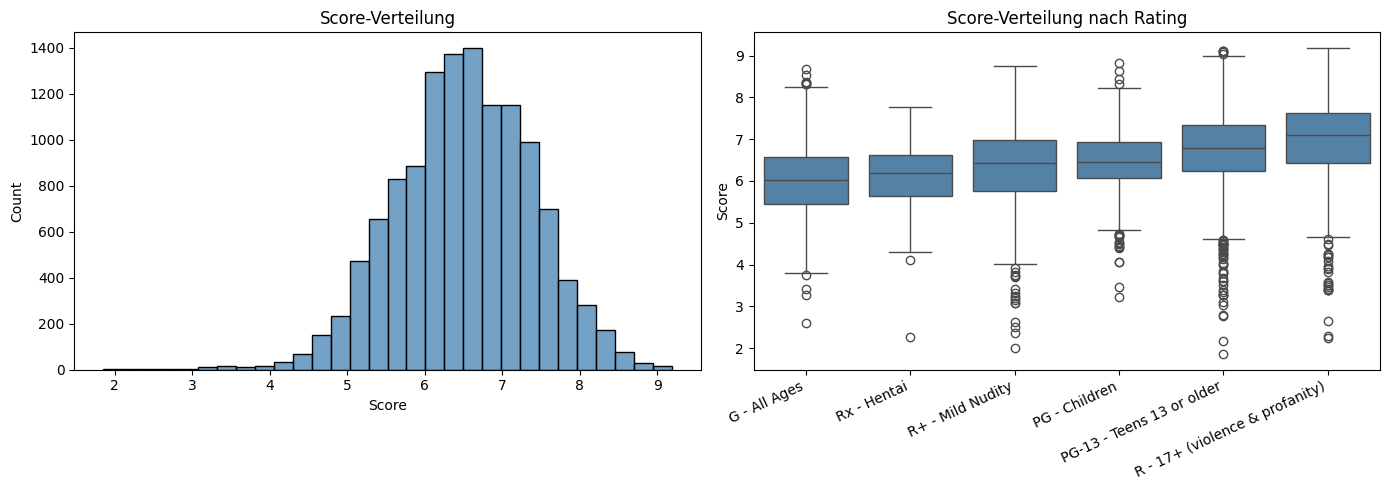

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score-Verteilung
sns.histplot(df_scored['Score'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Score-Verteilung')
axes[0].set_xlabel('Score')

# Score nach Rating (Boxplot, sortiert nach Median)
rating_order = (
    df_scored.groupby('Rating')['Score'].median()
    .sort_values()
    .index.tolist()
)
sns.boxplot(data=df_scored, x='Rating', y='Score', order=rating_order, ax=axes[1], color='steelblue')
axes[1].set_title('Score-Verteilung nach Rating')
axes[1].set_xlabel('')
plt.setp(axes[1].get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
plt.show()

### Score nach Type, Source und Genre

/tmp/ipykernel_33508/160723107.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(bp_data, labels=top_genres_sorted, vert=False, patch_artist=True,


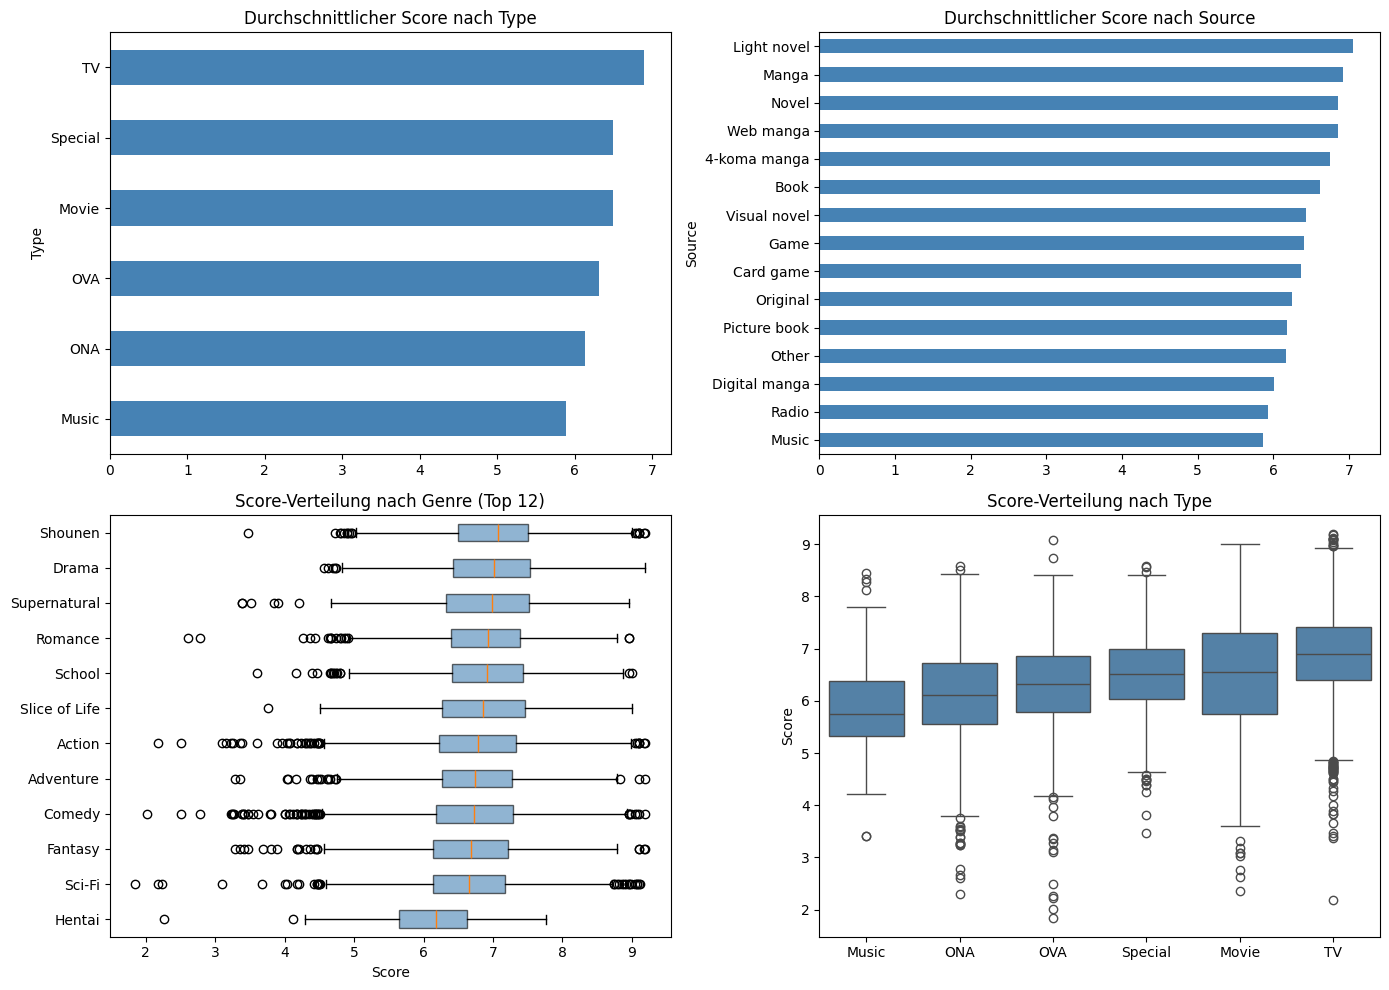

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Oben links: Durchschnittlicher Score nach Type
df_scored.groupby('Type')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Durchschnittlicher Score nach Type')

# Oben rechts: Durchschnittlicher Score nach Source
df_scored.groupby('Source')['Score'].mean().sort_values().plot(
    kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Durchschnittlicher Score nach Source')

# Unten links: Score-Verteilung nach Genre (Top 12 Genres, sortiert nach Median-Score)
all_genres_count = df_scored['Genres'].dropna().str.split(', ').explode().value_counts()
top_genres = all_genres_count.head(12).index.tolist()
top_genres_sorted = sorted(
    top_genres,
    key=lambda g: df_scored.loc[df_scored['Genres'].str.contains(g, na=False), 'Score'].median(),
)
bp_data = [df_scored.loc[df_scored['Genres'].str.contains(g, na=False), 'Score'].dropna().values
           for g in top_genres_sorted]
axes[1, 0].boxplot(bp_data, labels=top_genres_sorted, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1, 0].set_title('Score-Verteilung nach Genre (Top 12)')
axes[1, 0].set_xlabel('Score')

# Unten rechts: Score-Verteilung nach Type (Boxplot, sortiert nach Median)
type_order = df_scored.groupby('Type')['Score'].median().sort_values().index.tolist()
sns.boxplot(data=df_scored, x='Type', y='Score', order=type_order,
            ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Score-Verteilung nach Type')
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()

## 3. Feature Engineering (Basis für Empfehlung)

Wir bauen Roh-Features auf, die später in der Hybrid-Variante des Empfehlungssystems als Content-Vektor pro Anime dienen.

| Schritt | Feature | Quelle |
|---|---|---|
| 3.1 | 43 Genres (One-Hot) + `is_TV` | Genres-Spalte, Type-Spalte |
| 3.2 | `studio_avg_score` | Durchschnittsscore des besten Studios |
| 3.3 | Source & Rating (One-Hot) | je ≥ 20 Anime pro Kategorie |
| 3.4 | `duration_min` | Parser aus Duration-String |

**Bewusst ausgeschlossen:** Members und Episodes (zirkulär abhängig vom Score).

### 3.1 Genres (One-Hot) + Type-Flag `is_TV`

**Genres:** Jeder Anime hat eine kommaseparierte Liste (`"Action, Adventure, ..."`). One-Hot-kodiert ergibt das 43 binäre Spalten — eine pro Genre mit mindestens 20 Anime.

**`is_TV`:** Aus der Spalte `Type` (TV / Movie / OVA / ONA / Special / Music) — markiert nur die TV-Serien.

> *Nicht zu verwechseln mit `Source` in 3.3 (Manga / Original / Light Novel etc.) — `Type` ist das **Sende-Format**, `Source` ist die **Vorlage**.*

In [6]:
all_genre_counts = df_scored['Genres'].dropna().str.split(', ').explode().value_counts()
valid_genres = all_genre_counts[all_genre_counts >= 20].index.tolist()

print(f"Genres gesamt:           {all_genre_counts.shape[0]}")
print(f"Genres verwendet (>=20): {len(valid_genres)}")

for genre in valid_genres:
    df_scored[genre] = df_scored['Genres'].str.contains(genre, na=False).astype(int)

df_scored['is_TV'] = (df_scored['Type'] == 'TV').astype(int)

Genres gesamt:           43
Genres verwendet (>=20): 43


### 3.2 Studio-Qualitätsscore

Studios wie Madhouse, Bones oder Kyoto Animation produzieren konsistent besser bewertete Anime. Dieser Effekt ist in den Genre-Features unsichtbar — ein eigenes Feature ist nötig.

**Methode:** Für jedes Studio wird der Durchschnittsscore aller seiner Anime im Datensatz berechnet. Hat ein Anime mehrere Studios, wird das Maximum genommen (bestes Studio zählt).

In [7]:
studio_scores_map = {}
for _, row in df_scored.iterrows():
    if pd.isna(row['Studios']):
        continue
    for studio in str(row['Studios']).split(','):
        studio = studio.strip()
        if studio:
            studio_scores_map.setdefault(studio, []).append(row['Score'])

studio_avg = {s: np.mean(v) for s, v in studio_scores_map.items()}


def get_best_studio_score(studios_str):
    if pd.isna(studios_str):
        return np.nan
    scores = [studio_avg.get(s.strip()) for s in str(studios_str).split(',') if s.strip()]
    valid = [s for s in scores if s is not None]
    return max(valid) if valid else np.nan


global_mean_score = df_scored['Score'].mean()
df_scored['studio_avg_score'] = (
    df_scored['Studios'].apply(get_best_studio_score).fillna(global_mean_score)
)

print(f"Fehlende Studio-Werte (mit globalem Mittel {global_mean_score:.2f} gefuellt): "
      f"{df_scored['Studios'].isna().sum()}")
print(f"\nTop 10 Studios nach Durchschnittsscore:")
print(pd.Series(studio_avg).sort_values(ascending=False).head(10).round(2).to_string())

Fehlende Studio-Werte (mit globalem Mittel 6.51 gefuellt): 3511

Top 10 Studios nach Durchschnittsscore:
Studio Bind                        8.37
Egg Firm                           8.32
Studio Chizu                       8.10
Nippon Ramayana Film Co.           8.04
Colored-Pencil Animation Design    8.03
Samsara Animation Studio           8.00
Djinn Power                        7.83
Purple Cow Studio Japan            7.72
Code                               7.71
Shuka                              7.71


### 3.3 Source & Rating (One-Hot)

Source und Rating sind kategorial. One-Hot mit Schwelle >= 20 Anime pro Kategorie filtert seltene Auspraegungen. Hier entsteht der vollstaendige Roh-Feature-Satz, auf dem die anschliessende Korrelations- und Heatmap-Analyse die Reduktion motiviert.

In [8]:
source_dummies = pd.get_dummies(df_scored['Source'], prefix='src').astype(int)
valid_sources = [c for c in source_dummies.columns if source_dummies[c].sum() >= 20]
for col in valid_sources:
    df_scored[col] = source_dummies[col]

rating_dummies = pd.get_dummies(df_scored['Rating'], prefix='rating').astype(int)
valid_ratings = [c for c in rating_dummies.columns if rating_dummies[c].sum() >= 20]
for col in valid_ratings:
    df_scored[col] = rating_dummies[col]

print(f"Source-Kategorien (One-Hot): {len(valid_sources)}")
print(f"Rating-Kategorien (One-Hot): {len(valid_ratings)}")

Source-Kategorien (One-Hot): 13
Rating-Kategorien (One-Hot): 6


### 3.4 Episodendauer (`duration_min`)

`Duration` ist fuer 99.8 % der Anime gefuellt, aber als Freitext-String (`24 min. per ep.`, `1 hr. 45 min.`, `30 sec.`). Parser konvertiert in Minuten.

Korrelation mit Score ist mit |r| = 0.30 deutlich -- das ist auf Augenhoehe mit `is_TV`. Inhaltlich ist auch ein nichtlineares Muster sichtbar: sehr kurze Web-Shorts (<=5 min) scoren niedrig (~5.9), Standard-TV (16-25 min) und Filme (1-3 h) scoren hoch (~6.9 - 7.0). Lineare Modelle erfassen das nur teilweise, Tree-Modelle koennen den nichtlinearen Verlauf lernen.

In [9]:
import re


def parse_duration(s):
    """Konvertiere Duration-String in Minuten (float)."""
    if pd.isna(s):
        return np.nan
    s = s.strip()
    m = re.match(r'(\d+)\s*hr\.\s*(\d+)\s*min', s)
    if m:
        return int(m.group(1)) * 60 + int(m.group(2))
    m = re.match(r'(\d+)\s*hr', s)
    if m:
        return int(m.group(1)) * 60
    m = re.match(r'(\d+)\s*min', s)
    if m:
        return int(m.group(1))
    m = re.match(r'(\d+)\s*sec', s)
    if m:
        return int(m.group(1)) / 60
    return np.nan


df_scored['duration_min'] = df_scored['Duration'].apply(parse_duration)
median_dur = df_scored['duration_min'].median()
df_scored['duration_min'] = df_scored['duration_min'].fillna(median_dur)

print(f"Duration geparst: {df_scored['Duration'].notna().sum()} / {len(df_scored)} "
      f"({df_scored['Duration'].notna().mean()*100:.1f}%)")
print(f"Median: {median_dur:.1f} min  (für fehlende Werte verwendet)")
print(f"\nKorrelation duration_min ↔ Score: "
      f"{df_scored[['duration_min', 'Score']].corr().iloc[0, 1]:.4f}")

# Score-Verteilung nach Dauer-Bucket — zeigt das nichtlineare Muster
buckets = pd.cut(
    df_scored['duration_min'],
    bins=[0, 5, 15, 25, 35, 60, 180, 9999],
    labels=['≤5min', '6-15min', '16-25min', '26-35min', '36-60min', '1-3h', '>3h'],
)
print('\nScore-Mittelwert pro Dauer-Bucket:')
print(df_scored.groupby(buckets, observed=True)['Score'].agg(['count', 'mean']).round(3).to_string())

Duration geparst: 12398 / 12421 (99.8%)
Median: 24.0 min  (für fehlende Werte verwendet)

Korrelation duration_min ↔ Score: 0.2954

Score-Mittelwert pro Dauer-Bucket:
              count   mean
duration_min              
≤5min          2647  5.883
6-15min        1320  6.235
16-25min       4747  6.900
26-35min       1732  6.337
36-60min        801  6.374
1-3h           1174  7.003


## 4. Empfehlungssystem (Item-based Collaborative Filtering)

Aus den drei neuen Dateien (`animelist.csv`, `rating_complete.csv`, `watching_status.csv`) bauen wir ein Empfehlungssystem: *"Anime sind aehnlich, wenn dieselben User sie aehnlich bewerten oder gleich behandeln."*

Zwei Varianten zum Vergleich:
1. **Rating-basiert** -- nur Bewertungen aus abgeschlossenen Animes (`rating_complete.csv`, 57.6M Eintraege)
2. **Composite Engagement** -- alle Interaktionen (`animelist.csv`, ~109M Eintraege) kombiniert mit `watching_status`, damit auch Plan-to-Watch oder Dropped als Signal mitgenutzt werden

Beide Varianten nutzen die gleiche Pipeline (`Normalizer → NearestNeighbors`), nur die Eingabe-Matrix unterscheidet sich.

### 4.1 Datenaufbereitung

Aus der Vorab-Pruefung ergaben sich vier Cleanups fuer `animelist.csv`:

| Problem | Betroffen | Aktion |
|---|---|---|
| Duplikat-Paar (user 61960 / anime 17549) | 1 | entfernen |
| `watching_status` nicht in {1, 2, 3, 4, 6} | 540 | entfernen |
| `watched_episodes > 2x Episodes` (klare Fehler / int16-Overflow) | ~16.000 | entfernen |
| `watched_episodes > Episodes` aber ≤ 2x (legitime kleine Overshoots) | ~181.000 | auf `Episodes` cappen |

Gesamtverlust: ~0.015 % der Zeilen. `rating_complete.csv` wird ohne Cleanup uebernommen (war bereits perfekt).

In [10]:
al = pd.read_csv(
    '../data/animelist.csv',
    dtype={'user_id': 'int32', 'anime_id': 'int32', 'rating': 'int8',
           'watching_status': 'int8', 'watched_episodes': 'int32'},
)
n_initial = len(al)
print(f"Eingelesen: {n_initial:,d} Zeilen")

# 1. Duplikat
al = al.drop_duplicates(subset=['user_id', 'anime_id'])
print(f"  nach Duplikat-Drop:           {len(al):>11,d}")

# 2. Invalide watching_status
al = al[al['watching_status'].isin([1, 2, 3, 4, 6])]
print(f"  nach watching_status-Filter:  {len(al):>11,d}")

# 3. watched_episodes Anomalien
anime_eps = pd.read_csv('../data/anime.csv', usecols=['MAL_ID', 'Episodes'])
anime_eps['Episodes'] = pd.to_numeric(anime_eps['Episodes'].replace('Unknown', np.nan), errors='coerce')
al = al.merge(anime_eps, left_on='anime_id', right_on='MAL_ID', how='left').drop(columns='MAL_ID')

mask_drop = al['Episodes'].notna() & (al['watched_episodes'] > 2 * al['Episodes'])
n_drop = mask_drop.sum()
al = al[~mask_drop]
print(f"  nach >2x-Episodes-Drop:       {len(al):>11,d}  (-{n_drop:,d})")

mask_cap = al['Episodes'].notna() & (al['watched_episodes'] > al['Episodes'])
n_cap = mask_cap.sum()
al.loc[mask_cap, 'watched_episodes'] = al.loc[mask_cap, 'Episodes'].astype('int32')
al = al.drop(columns='Episodes')
print(f"  watched_episodes gecapped:    {n_cap:>11,d}")

print(f"\nFinal: {len(al):,d} Zeilen  ({(1 - len(al)/n_initial) * 100:.3f}% verworfen)")

Eingelesen: 109,224,747 Zeilen


  nach Duplikat-Drop:           109,224,746


  nach watching_status-Filter:  109,224,206


  nach >2x-Episodes-Drop:       109,208,207  (-15,999)


  watched_episodes gecapped:        181,229

Final: 109,208,207 Zeilen  (0.015% verworfen)


### 4.2 Wer ist ein "Member"? — Wie verteilt sich das User-Anime-Verhalten?

Die `Members`-Zahl in `anime.csv` aggregiert eine **Mischung** aus Verhaltensweisen. Jeder Eintrag in `animelist.csv` ist genau ein Member-Eintrag -- mit zusaetzlichen Spalten `watching_status` und `rating`. Vor der Engagement-Definition lohnt der Blick auf das tatsaechliche Verhalten:

- **Wer ist hinter den 109M Eintraegen?** (Status-Verteilung)
- **Wer bewertet ueberhaupt?** (Rating-Rate pro Status)
- **Welche Bewertungen geben Bewertende?** (Rating-Verteilung pro Status)

Diese Befunde motivieren direkt die Engagement-Werte in 6.5.

Pro Status:
                             n  pct_total  rated_pct  avg_rating
status_label                                                    
Plan to Watch       27938231.0      25.58       0.98        7.87
Currently Watching   5227147.0       4.79      28.40        7.89
Completed           68076332.0      62.34      84.65        7.51
On Hold              3700225.0       3.39      28.54        7.21
Dropped              4266272.0       3.91      45.64        4.81


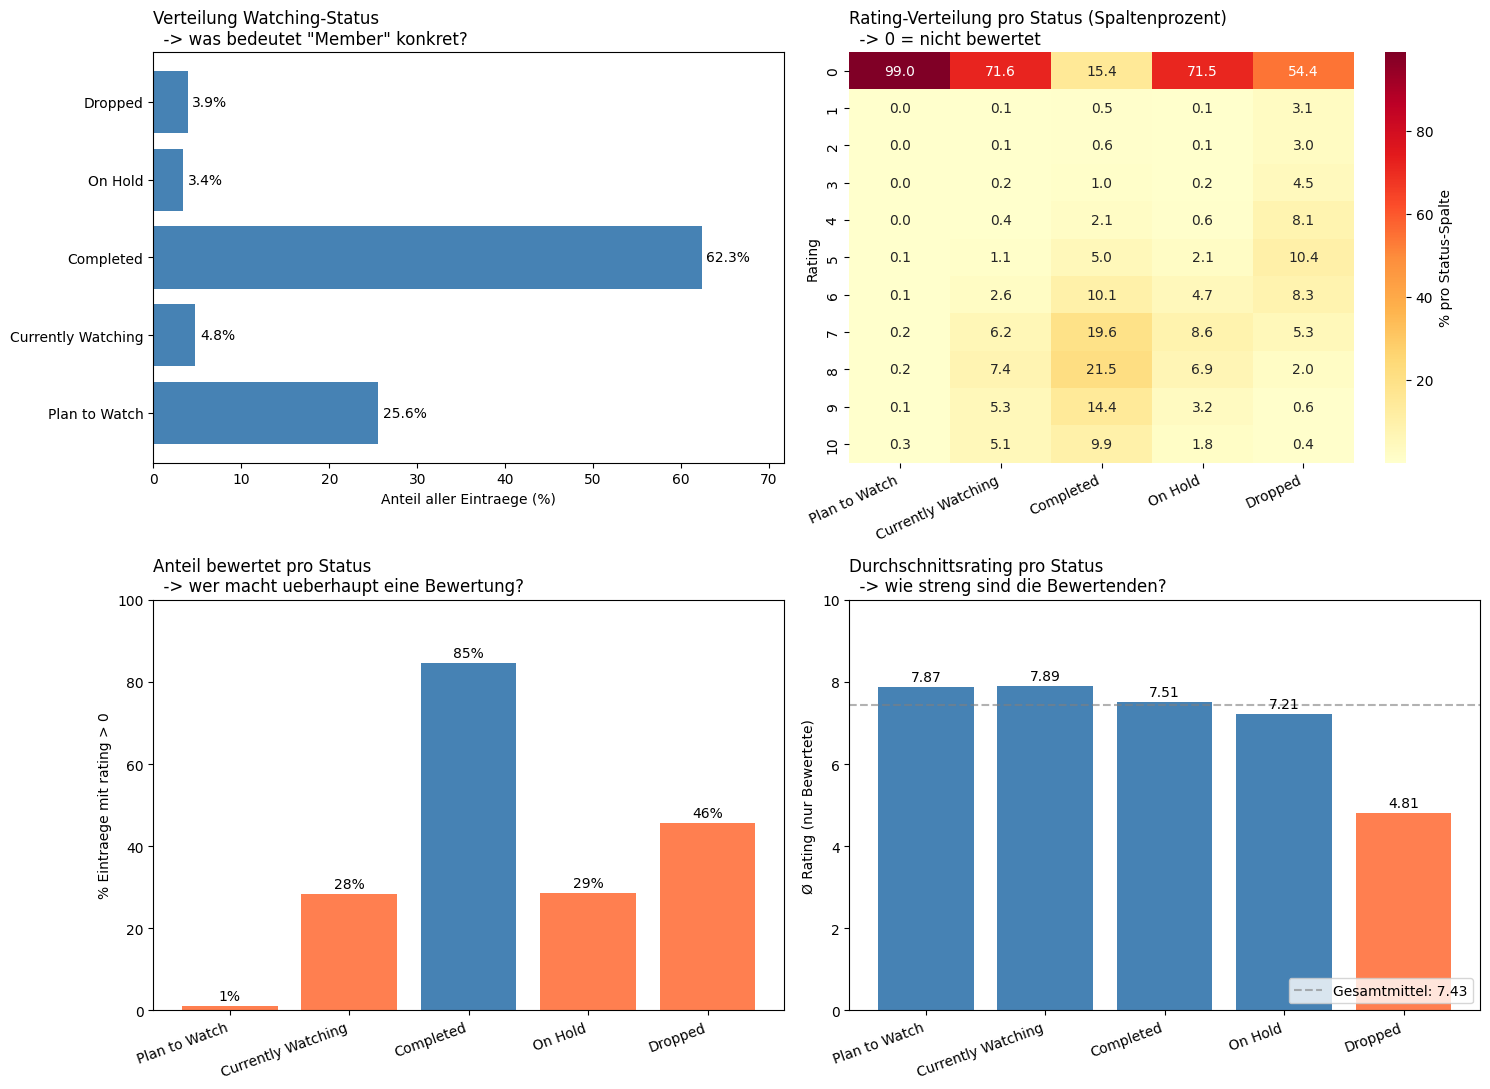

In [11]:
# Status-Labels und einheitliche Reihenfolge fuer die Plots
status_label_map = {1: 'Currently Watching', 2: 'Completed', 3: 'On Hold', 4: 'Dropped', 6: 'Plan to Watch'}
al['status_label'] = al['watching_status'].map(status_label_map)
status_order = ['Plan to Watch', 'Currently Watching', 'Completed', 'On Hold', 'Dropped']

# Aggregate pro Status: n, % bewertet, Avg rating among rated
def status_stats(df):
    rated = df[df['rating'] > 0]
    return pd.Series({
        'n': len(df),
        'pct_total': len(df) / len(al) * 100,
        'rated_pct': len(rated) / len(df) * 100 if len(df) else 0,
        'avg_rating': rated['rating'].mean() if len(rated) else np.nan,
    })


stats = al.groupby('status_label').apply(status_stats).reindex(status_order).round(2)
print('Pro Status:')
print(stats.to_string())

# 2x2 Plot
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (A) Status-Verteilung
ax = axes[0, 0]
bars = ax.barh(stats.index, stats['pct_total'], color='steelblue')
ax.set_xlabel('Anteil aller Eintraege (%)')
ax.set_title('Verteilung Watching-Status\n  -> was bedeutet "Member" konkret?', loc='left')
for bar, val in zip(bars, stats['pct_total']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center')
ax.set_xlim(0, max(stats['pct_total']) * 1.15)

# (B) Heatmap: Rating-Verteilung pro Status (Spaltenprozent, inkl. rating=0)
ct = pd.crosstab(al['rating'], al['status_label'])[status_order]
ct_pct = (ct / ct.sum(axis=0) * 100)
ax = axes[0, 1]
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '% pro Status-Spalte'})
ax.set_title('Rating-Verteilung pro Status (Spaltenprozent)\n  -> 0 = nicht bewertet', loc='left')
ax.set_ylabel('Rating')
ax.set_xlabel('')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')

# (C) % bewertet pro Status
ax = axes[1, 0]
colors_c = ['steelblue' if v >= 50 else 'coral' for v in stats['rated_pct']]
bars = ax.bar(stats.index, stats['rated_pct'], color=colors_c)
ax.set_ylabel('% Eintraege mit rating > 0')
ax.set_title('Anteil bewertet pro Status\n  -> wer macht ueberhaupt eine Bewertung?', loc='left')
ax.set_ylim(0, 100)
for bar, val in zip(bars, stats['rated_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f'{val:.0f}%', ha='center')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

# (D) Avg rating among rated pro Status
ax = axes[1, 1]
overall_avg = al.loc[al['rating'] > 0, 'rating'].mean()
colors_d = ['steelblue' if v > 6 else 'coral' for v in stats['avg_rating']]
bars = ax.bar(stats.index, stats['avg_rating'], color=colors_d)
ax.axhline(overall_avg, color='gray', linestyle='--', alpha=0.6,
           label=f'Gesamtmittel: {overall_avg:.2f}')
ax.set_ylabel('Ø Rating (nur Bewertete)')
ax.set_title('Durchschnittsrating pro Status\n  -> wie streng sind die Bewertenden?', loc='left')
ax.set_ylim(0, 10)
for bar, val in zip(bars, stats['avg_rating']):
    if not pd.isna(val):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.15, f'{val:.2f}', ha='center')
ax.legend(loc='lower right')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

# status_label-Spalte wieder droppen (wird nicht weiter gebraucht)
al = al.drop(columns='status_label')

### 4.3 Helper-Funktionen + Pipeline

`build_sparse(df, value_col)` baut eine `anime x user`-Sparse-Matrix. `find_anime(name)` sucht nach Namen (inkl. englischer Name). `recommend(pipe, ...)` empfiehlt die `top_k` aehnlichsten Animes zu einem Such-Anime — wendet alle Pipeline-Transformer auf den Anfrage-Vektor an und nutzt `NearestNeighbors.kneighbors()` der letzten Pipeline-Stufe. `resolve_query(name)` findet einen Anime und gibt MAL_ID + Anzeigename zurueck.

Die Pipeline `Normalizer(l2) → NearestNeighbors(euclidean)` ist mathematisch aequivalent zu Cosine-Similarity-Suche, aber jede Stufe macht echt Arbeit (L2-Normalisierung dann euklidische Distanz auf normierten Vektoren = sqrt(2(1-cos))).

In [12]:
from scipy.sparse import csr_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.neighbors import NearestNeighbors

anime_info = pd.read_csv(
    '../data/anime.csv',
    usecols=['MAL_ID', 'Name', 'English name', 'Score', 'Type', 'Genres'],
).replace('Unknown', np.nan)
anime_info['Score'] = pd.to_numeric(anime_info['Score'], errors='coerce')
anime_info = anime_info.set_index('MAL_ID')


def display_name(info_row):
    """Englischer Name wenn vorhanden, sonst Originalname."""
    en = info_row.get('English name')
    if isinstance(en, str) and en.strip():
        return en
    return info_row['Name']


def build_sparse(df, value_col):
    """Baut sparse (anime x user)-Matrix."""
    anime_ids = np.sort(df['anime_id'].unique())
    user_ids = np.sort(df['user_id'].unique())
    aid_to_idx = {aid: i for i, aid in enumerate(anime_ids)}
    uid_to_idx = {uid: i for i, uid in enumerate(user_ids)}

    rows = df['anime_id'].map(aid_to_idx).values
    cols = df['user_id'].map(uid_to_idx).values
    vals = df[value_col].astype('float32').values

    X = csr_matrix((vals, (rows, cols)), shape=(len(anime_ids), len(user_ids)))
    print(f"Matrix: {X.shape}  nnz={X.nnz:,d}  density={X.nnz/(X.shape[0]*X.shape[1])*100:.3f}%")
    return X, aid_to_idx, anime_ids


def find_anime(name_substring):
    """Suche Anime per Substring -- gibt DataFrame zurueck (Name + English name)."""
    s = name_substring.lower()
    mask = (
        anime_info['Name'].str.lower().str.contains(s, na=False)
        | anime_info['English name'].fillna('').str.lower().str.contains(s, na=False)
    )
    return anime_info[mask].reset_index()


def recommend(pipe, X, aid_to_idx, anime_ids, mal_id, top_k=10):
    """Empfiehlt top_k Animes aehnlich zu mal_id (bereits aufgeloest)."""
    if mal_id not in aid_to_idx:
        return None
    target_idx = aid_to_idx[mal_id]
    query = X[target_idx]
    for _, step in pipe.steps[:-1]:
        query = step.transform(query)
    distances, indices = pipe.steps[-1][1].kneighbors(query, n_neighbors=top_k + 1)

    out = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx == target_idx:
            continue
        info = anime_info.loc[anime_ids[idx]]
        out.append({
            'Name': display_name(info),
            'Type': info['Type'],
            'Score': info['Score'],
            'Similarity': 1 - dist ** 2 / 2,
        })
        if len(out) >= top_k:
            break
    return pd.DataFrame(out).round(3)


def resolve_query(query_name):
    """Findet den ersten Treffer fuer query_name und gibt (mal_id, display_name, n_matches) zurueck."""
    matches = find_anime(query_name)
    if matches.empty:
        return None, None, 0
    target = matches.iloc[0]
    return int(target['MAL_ID']), display_name(target), len(matches)

### 4.4 Variante 1: Rating-basierte CF

Eingabematrix: nur Bewertungen aus `rating_complete.csv` (abgeschlossene + bewertete Animes). 57.6M Bewertungen, 16.872 Animes x 310.059 User. Saubere Daten, aber kein Signal fuer Animes die kein User abgeschlossen + bewertet hat.

In [13]:
rc = pd.read_csv(
    '../data/rating_complete.csv',
    dtype={'user_id': 'int32', 'anime_id': 'int32', 'rating': 'int8'},
)

X_rating, aid_to_idx_r, anime_ids_r = build_sparse(rc, 'rating')

cf_rating = Pipeline([
    ('normalize', Normalizer(norm='l2')),
    ('knn', NearestNeighbors(metric='euclidean', algorithm='brute', n_jobs=-1)),
])
cf_rating.fit(X_rating)

mal_id, name, n_matches = resolve_query('Vinland Saga')
print(f"\nQuery: {name}  ({n_matches} Treffer)")
print(recommend(cf_rating, X_rating, aid_to_idx_r, anime_ids_r, mal_id, top_k=10).to_string(index=False))

Matrix: (16872, 310059)  nnz=57,633,278  density=1.102%



Query: Vinland Saga  (1 Treffer)


                           Name Type  Score  Similarity
                      Dr. Stone   TV   8.34       0.565
  Demon Slayer:Kimetsu no Yaiba   TV   8.62       0.562
Attack on Titan Season 3 Part 2   TV   9.10       0.556
         The Promised Neverland   TV   8.65       0.540
       Attack on Titan Season 3   TV   8.59       0.538
                         Dororo   TV   8.19       0.534
              Mob Psycho 100 II   TV   8.84       0.529
             My Hero Academia 3   TV   8.25       0.505
       One Punch Man 2nd Season   TV   7.41       0.503
                   Tower of God   TV   7.66       0.502


### 4.5 Variante 2: Composite Engagement Score

Statt nur `rating`, kombinieren wir Status + Rating zu einem Engagement-Wert pro (User, Anime). So nutzen wir auch die ~47M Eintraege ohne Rating (Plan-to-Watch, Currently-Watching, Dropped etc.).

Die Wahl der Default-Werte ist direkt aus der Analyse in 6.2 motiviert:

| `watching_status` | Default-Engagement (wenn `rating == 0`) | Begruendung |
|---|---|---|
| 1 = Currently Watching | **6** | Avg-Rating bei tatsaechlich Bewertenden = 7.89 -- Loyalitaets-Signal |
| 2 = Completed | **5** | Avg-Rating bei Bewertenden = 7.51; konservativer fuer Unbewertete |
| 3 = On Hold | **4** | Avg-Rating 7.21 bei Bewertenden, aber Mehrheit unentschieden |
| 4 = Dropped | **2** | Avg-Rating 4.81 bei Bewertenden -- klares Anti-Signal |
| 6 = Plan to Watch | **3** | Faktisch nicht geschaut -- nur Interesse-Lesezeichen |

Wenn `rating > 0`, wird der Engagement-Wert durch das Rating selbst ueberschrieben.

In [14]:
status_default = {1: 6.0, 2: 5.0, 3: 4.0, 4: 2.0, 6: 3.0}
al['engagement'] = al['watching_status'].map(status_default).astype('float32')

mask_rated = al['rating'] > 0
al.loc[mask_rated, 'engagement'] = al.loc[mask_rated, 'rating'].astype('float32')

print(f"Engagement-Verteilung (n={len(al):,d}):")
print(al['engagement'].describe().round(2).to_string())

print()
X_engagement, aid_to_idx_e, anime_ids_e = build_sparse(al, 'engagement')

cf_engagement = Pipeline([
    ('normalize', Normalizer(norm='l2')),
    ('knn', NearestNeighbors(metric='euclidean', algorithm='brute', n_jobs=-1)),
])
cf_engagement.fit(X_engagement)

mal_id, name, n_matches = resolve_query('Vinland Saga')
print(f"\nQuery: {name}  ({n_matches} Treffer)")
print(recommend(cf_engagement, X_engagement, aid_to_idx_e, anime_ids_e, mal_id, top_k=10).to_string(index=False))

Engagement-Verteilung (n=109,208,207):


count    1.092082e+08
mean     5.830000e+00
std      2.400000e+00
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      8.000000e+00
max      1.000000e+01



Matrix: (17562, 325754)  nnz=109,208,207  density=1.909%



Query: Vinland Saga  (1 Treffer)


                           Name Type  Score  Similarity
                      Dr. Stone   TV   8.34       0.674
  Demon Slayer:Kimetsu no Yaiba   TV   8.62       0.666
                         Dororo   TV   8.19       0.650
Attack on Titan Season 3 Part 2   TV   9.10       0.647
         The Promised Neverland   TV   8.65       0.645
       Attack on Titan Season 3   TV   8.59       0.632
                     Fire Force   TV   7.68       0.622
              Mob Psycho 100 II   TV   8.84       0.619
             My Hero Academia 4   TV   8.06       0.598
       One Punch Man 2nd Season   TV   7.41       0.597


### 4.6 Vergleich beider Varianten

Drei Beispiel-Animes durch beide Pipelines schicken und nebeneinander vergleichen. Wenn die Empfehlungen sich stark ueberschneiden, war das zusaetzliche Status-Signal nicht entscheidend. Wenn sie stark auseinandergehen, holt die Engagement-Variante andere Aspekte raus (z.B. *was Leute "vorhaben zu schauen"* statt nur *was sie bewerten*).

In [15]:
examples = ['Vinland Saga', 'Fullmetal Alchemist: Brotherhood', 'Cowboy Bebop', 'K-On!']

for q in examples:
    mal_id, name, n_matches = resolve_query(q)
    print(f"\n{'=' * 100}")
    if mal_id is None:
        print(f"Query: {q}  -> keine Treffer")
        continue
    treffer_note = '' if n_matches == 1 else f'  ({n_matches} Treffer, erster verwendet)'
    print(f"Query: {name}{treffer_note}")
    print('=' * 100)

    r1 = recommend(cf_rating, X_rating, aid_to_idx_r, anime_ids_r, mal_id, top_k=5)
    r2 = recommend(cf_engagement, X_engagement, aid_to_idx_e, anime_ids_e, mal_id, top_k=5)

    if r1 is None or r2 is None:
        print('  Anime nicht in einer der Matrizen')
        continue

    side = pd.DataFrame({
        'Rang': range(1, 6),
        'Rating-basiert': [f"{n} ({s:.2f})" for n, s in zip(r1['Name'], r1['Similarity'])],
        'Composite Engagement': [f"{n} ({s:.2f})" for n, s in zip(r2['Name'], r2['Similarity'])],
    })
    print(side.to_string(index=False))


Query: Vinland Saga


 Rang                         Rating-basiert                   Composite Engagement
    1                       Dr. Stone (0.56)                       Dr. Stone (0.67)
    2   Demon Slayer:Kimetsu no Yaiba (0.56)   Demon Slayer:Kimetsu no Yaiba (0.67)
    3 Attack on Titan Season 3 Part 2 (0.56)                          Dororo (0.65)
    4          The Promised Neverland (0.54) Attack on Titan Season 3 Part 2 (0.65)
    5        Attack on Titan Season 3 (0.54)          The Promised Neverland (0.64)

Query: Fullmetal Alchemist:Brotherhood  (3 Treffer, erster verwendet)


 Rang                             Rating-basiert                       Composite Engagement
    1                     Attack on Titan (0.67)                          Death Note (0.75)
    2                          Death Note (0.65)                     Attack on Titan (0.75)
    3 Code Geass:Lelouch of the Rebellion (0.63)                         Steins;Gate (0.73)
    4                         Steins;Gate (0.63) Code Geass:Lelouch of the Rebellion (0.73)
    5                       One Punch Man (0.63)                       One Punch Man (0.71)

Query: Cowboy Bebop  (4 Treffer, erster verwendet)


 Rang                 Rating-basiert           Composite Engagement
    1  Cowboy Bebop:The Movie (0.61)        Samurai Champloo (0.69)
    2        Samurai Champloo (0.58) Neon Genesis Evangelion (0.66)
    3 Neon Genesis Evangelion (0.56)           Gurren Lagann (0.65)
    4                  Trigun (0.53)                  Trigun (0.63)
    5           Gurren Lagann (0.53)                    FLCL (0.62)

Query: K-ON!  (7 Treffer, erster verwendet)


 Rang                           Rating-basiert                     Composite Engagement
    1                    K-ON! Season 2 (0.78)                    K-ON! Season 2 (0.83)
    2                   K-ON! The Movie (0.61) The Melancholy of Haruhi Suzumiya (0.65)
    3                K-On!: Live House! (0.56)                         Toradora! (0.64)
    4 The Melancholy of Haruhi Suzumiya (0.56)                        Lucky☆Star (0.63)
    5                         Toradora! (0.55)                   K-ON! The Movie (0.63)


### 4.7 Evaluierung — wie gut sind die Empfehlungen quantitativ?

Bisher haben wir Empfehlungen qualitativ verglichen ("Vinland Saga -> Dr. Stone, ..."). Jetzt: **Hold-Out Evaluation** mit echten Metriken.

**Vorgehen (Leave-One-Out pro User):**
1. Sample 500 User mit >= 20 abgeschlossenen + bewerteten Animes (aus `rating_complete`)
2. Pro User:
   - **Seed** = hoechstbewerteter Anime
   - **Truth** = alle anderen Animes des Users mit `rating >= 8`
3. Top-10 Empfehlungen vom Recommender fuer den Seed generieren
4. Frage: Wie viele Truth-Animes sind in den Top-10?

**Metriken (alle @ K=10):**
- **Hit@10**: Mind. ein Truth-Treffer in Top-10? (binaer, anteilig)
- **Precision@10**: Anteil der 10 Empfehlungen, die Truth sind
- **NDCG@10**: Rang-bewusst -- Treffer auf Platz 1 zaehlt mehr als Platz 10

In [16]:
EVAL_N_USERS = 500
EVAL_MIN_RATINGS = 20
EVAL_TRUTH_THRESHOLD = 8
EVAL_K = 10
RANDOM_STATE = 42

# Eligible user (>= min ratings)
user_counts = rc.groupby('user_id').size()
eligible_users = user_counts[user_counts >= EVAL_MIN_RATINGS].index.values
print(f"User mit >= {EVAL_MIN_RATINGS} Bewertungen: {len(eligible_users):,d}")

rng = np.random.RandomState(RANDOM_STATE)
sampled_uids = rng.choice(eligible_users, size=EVAL_N_USERS, replace=False)
rc_sample = rc[rc['user_id'].isin(sampled_uids)]

# Eval-Set bauen: (seed_aid, truth_aids) pro User
eval_set = []
for uid, user_df in rc_sample.groupby('user_id'):
    sorted_df = user_df.sort_values('rating', ascending=False)
    seed_aid = int(sorted_df.iloc[0]['anime_id'])
    rest = sorted_df.iloc[1:]
    truth = set(int(x) for x in rest.loc[rest['rating'] >= EVAL_TRUTH_THRESHOLD, 'anime_id'])
    if truth:
        eval_set.append((seed_aid, truth))

truth_sizes = [len(t) for _, t in eval_set]
print(f"\nEval-Set: {len(eval_set)} (seed, truth)-Paare")
print(f"Truth-Set Groesse: median={np.median(truth_sizes):.0f}, mean={np.mean(truth_sizes):.1f}, max={max(truth_sizes)}")

User mit >= 20 Bewertungen: 265,263



Eval-Set: 500 (seed, truth)-Paare
Truth-Set Groesse: median=78, mean=124.0, max=1552


#### Evaluierungs-Funktion + erste Messung von Variante 1 und 2

In [17]:
def evaluate_recommender(pipe, X, aid_to_idx, anime_ids, eval_set, k=10):
    """Hold-Out Evaluation -- batched fuer Effizienz."""
    valid = [(s, t) for s, t in eval_set if s in aid_to_idx]
    if not valid:
        return {'n_evaluated': 0, 'Hit@K': 0.0, 'Precision@K': 0.0, 'NDCG@K': 0.0}

    seed_indices = [aid_to_idx[s] for s, _ in valid]
    Q = X[seed_indices]
    for _, step in pipe.steps[:-1]:
        Q = step.transform(Q)
    _, indices_batch = pipe.steps[-1][1].kneighbors(Q, n_neighbors=k + 1)

    hits, precisions, ndcgs = [], [], []
    for i, (seed_aid, truth_set) in enumerate(valid):
        rec_aids = []
        for ri in indices_batch[i]:
            aid = int(anime_ids[ri])
            if aid != seed_aid:
                rec_aids.append(aid)
            if len(rec_aids) >= k:
                break

        rec_set = set(rec_aids)
        truth_clean = truth_set - {seed_aid}
        if not truth_clean:
            continue

        hits.append(1 if rec_set & truth_clean else 0)
        precisions.append(len(rec_set & truth_clean) / k)

        dcg = sum((1 if rec_aids[j] in truth_clean else 0) / np.log2(j + 2)
                  for j in range(len(rec_aids)))
        ideal = min(len(truth_clean), k)
        idcg = sum(1 / np.log2(j + 2) for j in range(ideal))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

    return {
        'n_evaluated': len(hits),
        'Hit@K': float(np.mean(hits)) if hits else 0.0,
        'Precision@K': float(np.mean(precisions)) if precisions else 0.0,
        'NDCG@K': float(np.mean(ndcgs)) if ndcgs else 0.0,
    }


# Variante 1 + 2 evaluieren
res_rating = evaluate_recommender(cf_rating, X_rating, aid_to_idx_r, anime_ids_r, eval_set, k=EVAL_K)
res_engagement = evaluate_recommender(cf_engagement, X_engagement, aid_to_idx_e, anime_ids_e, eval_set, k=EVAL_K)

print(f"Variante 1 (Rating-basiert):       "
      f"Hit@10 = {res_rating['Hit@K']*100:5.1f}%   "
      f"Precision@10 = {res_rating['Precision@K']:.4f}   "
      f"NDCG@10 = {res_rating['NDCG@K']:.4f}   "
      f"(n={res_rating['n_evaluated']})")
print(f"Variante 2 (Composite Engagement): "
      f"Hit@10 = {res_engagement['Hit@K']*100:5.1f}%   "
      f"Precision@10 = {res_engagement['Precision@K']:.4f}   "
      f"NDCG@10 = {res_engagement['NDCG@K']:.4f}   "
      f"(n={res_engagement['n_evaluated']})")

Variante 1 (Rating-basiert):       Hit@10 =  89.8%   Precision@10 = 0.4124   NDCG@10 = 0.4455   (n=500)
Variante 2 (Composite Engagement): Hit@10 =  90.4%   Precision@10 = 0.4076   NDCG@10 = 0.4420   (n=500)


### 4.8 Variante 3: Hybrid — CF + Content-Features

Der Engagement-Vektor pro Anime wird um Content-Features ergaenzt (Studio-Score, Episodendauer, TV-Flag, Source/Rating-One-Hot, Genres). Effekt: zwei Anime gelten als aehnlich, wenn sie *sowohl von aehnlichen Usern bewertet* als auch *inhaltlich aehnlich* sind.

**Mathematisch:** beide Teile (CF und Content) werden separat L2-normalisiert, dann mit `sqrt(α)` bzw. `sqrt(1-α)` skaliert und konkateniert. Das ergibt:

`sim_hybrid(A, B) = α · sim_CF(A, B) + (1 - α) · sim_Content(A, B)`

Wir starten mit **α = 0.7** (70 % CF, 30 % Content). Spaeter waere α durch den Hold-Out-Score tunbar.

In [18]:
from scipy.sparse import hstack
from sklearn.preprocessing import normalize as sk_normalize

# Content-Features fuer ALLE 17.562 Animes (auch ohne Score)
all_anime = pd.read_csv('../data/anime.csv').replace('Unknown', np.nan).set_index('MAL_ID')

all_anime['is_TV'] = (all_anime['Type'] == 'TV').astype(int)
all_anime['duration_min'] = all_anime['Duration'].apply(parse_duration).fillna(24)
all_anime['duration_norm'] = all_anime['duration_min'].clip(upper=180) / 180

# studio_avg_score fuer alle Animes
def best_studio_score(studios_str):
    if pd.isna(studios_str):
        return np.nan
    scores = [studio_avg.get(s.strip()) for s in str(studios_str).split(',') if s.strip()]
    valid = [s for s in scores if s is not None]
    return max(valid) if valid else np.nan

all_anime['studio_avg'] = all_anime['Studios'].apply(best_studio_score).fillna(df_scored['Score'].mean())
all_anime['studio_norm'] = ((all_anime['studio_avg'] - 5) / 4).clip(0, 1)

for g in valid_genres:
    all_anime[g] = all_anime['Genres'].str.contains(g, na=False).astype(int)

src_d = pd.get_dummies(all_anime['Source'], prefix='src').astype(int)
for col in valid_sources:
    all_anime[col] = src_d[col] if col in src_d.columns else 0
rating_d = pd.get_dummies(all_anime['Rating'], prefix='rating').astype(int)
for col in valid_ratings:
    all_anime[col] = rating_d[col] if col in rating_d.columns else 0

content_cols = ['is_TV', 'duration_norm', 'studio_norm'] + valid_sources + valid_ratings + valid_genres
content_matrix = all_anime.reindex(anime_ids_e)[content_cols].fillna(0).values.astype('float32')
print(f"Content-Features pro Anime: {content_matrix.shape[1]}")

# Beide Teile separat L2-normalisieren, mit sqrt(α) und sqrt(1-α) gewichten
ALPHA = 0.7
X_eng_norm = sk_normalize(X_engagement, norm='l2', axis=1)
content_norm = sk_normalize(csr_matrix(content_matrix), norm='l2', axis=1)

X_hybrid = hstack([
    X_eng_norm * np.sqrt(ALPHA),
    content_norm * np.sqrt(1 - ALPHA),
]).tocsr().astype('float32')

print(f"Hybrid-Matrix: {X_hybrid.shape}")
print(f"  CF-Teil:      {X_engagement.shape[1]:>6d} Spalten   Gewicht sqrt({ALPHA}) = {np.sqrt(ALPHA):.3f}")
print(f"  Content-Teil: {content_matrix.shape[1]:>6d} Spalten   Gewicht sqrt({1-ALPHA}) = {np.sqrt(1-ALPHA):.3f}")

cf_hybrid = Pipeline([
    ('normalize', Normalizer(norm='l2')),
    ('knn', NearestNeighbors(metric='euclidean', algorithm='brute', n_jobs=-1)),
])
cf_hybrid.fit(X_hybrid)

mal_id, name, n_matches = resolve_query('Vinland Saga')
print(f"\nQuery: {name}")
print(recommend(cf_hybrid, X_hybrid, aid_to_idx_e, anime_ids_e, mal_id, top_k=10).to_string(index=False))

Content-Features pro Anime: 65


Hybrid-Matrix: (17562, 325819)
  CF-Teil:      325754 Spalten   Gewicht sqrt(0.7) = 0.837
  Content-Teil:     65 Spalten   Gewicht sqrt(0.30000000000000004) = 0.548



Query: Vinland Saga


                           Name Type  Score  Similarity
                         Dororo   TV   8.19       0.660
  Demon Slayer:Kimetsu no Yaiba   TV   8.62       0.658
Attack on Titan Season 3 Part 2   TV   9.10       0.626
       Attack on Titan Season 3   TV   8.59       0.616
                   Golden Kamuy   TV   7.83       0.613
                      Dr. Stone   TV   8.34       0.609
       Attack on Titan Season 2   TV   8.45       0.587
  The Rising of the Shield Hero   TV   8.00       0.583
                     Fire Force   TV   7.68       0.574
           Inuyashiki:Last Hero   TV   7.70       0.573


### 4.9 Drei-Wege-Vergleich

Alle drei Varianten mit derselben Eval-Methodik bewertet. Tabelle + Plot zeigen welche Variante quantitativ vorne liegt -- und das kontrastiert mit dem qualitativen Eindruck aus 6.6.

Variante 3 (Hybrid alpha=0.7):     Hit@10 =  89.8%   Precision@10 = 0.3510   NDCG@10 = 0.3822   (n=500)

            Variante  n_eval  Hit@10 (%)  Precision@10  NDCG@10
      Rating-basiert     500        89.8        0.4124   0.4455
Composite Engagement     500        90.4        0.4076   0.4420
  Hybrid (alpha=0.7)     500        89.8        0.3510   0.3822


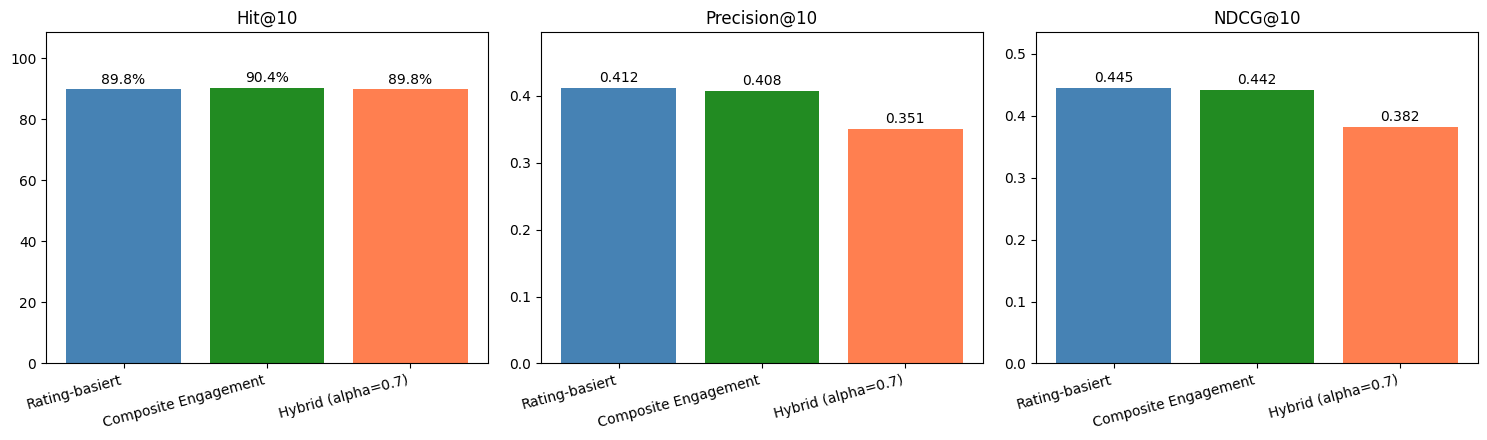

In [19]:
res_hybrid = evaluate_recommender(cf_hybrid, X_hybrid, aid_to_idx_e, anime_ids_e, eval_set, k=EVAL_K)

print(f"Variante 3 (Hybrid alpha={ALPHA}):     "
      f"Hit@10 = {res_hybrid['Hit@K']*100:5.1f}%   "
      f"Precision@10 = {res_hybrid['Precision@K']:.4f}   "
      f"NDCG@10 = {res_hybrid['NDCG@K']:.4f}   "
      f"(n={res_hybrid['n_evaluated']})")

# Vergleichstabelle
variants = ['Rating-basiert', 'Composite Engagement', f'Hybrid (alpha={ALPHA})']
all_results = [res_rating, res_engagement, res_hybrid]
df_results = pd.DataFrame({
    'Variante': variants,
    'n_eval': [r['n_evaluated'] for r in all_results],
    'Hit@10 (%)': [round(r['Hit@K'] * 100, 1) for r in all_results],
    'Precision@10': [round(r['Precision@K'], 4) for r in all_results],
    'NDCG@10': [round(r['NDCG@K'], 4) for r in all_results],
})
print(f"\n{df_results.to_string(index=False)}")

# Bar-Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ['steelblue', 'forestgreen', 'coral']

metrics_meta = [
    ('Hit@K', 'Hit@10', 100, '{:.1f}%'),
    ('Precision@K', 'Precision@10', 1, '{:.3f}'),
    ('NDCG@K', 'NDCG@10', 1, '{:.3f}'),
]

for ax, (key, title, scale, fmt) in zip(axes, metrics_meta):
    vals = [r[key] * scale for r in all_results]
    bars = ax.bar(variants, vals, color=colors)
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.20)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.02, fmt.format(v), ha='center')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

### 4.10 Diversity & Novelty — über Hit/Precision/NDCG hinaus

Hit@10, Precision@10 und NDCG@10 messen *nur* die Übereinstimmung mit den bekannten User-Praeferenzen. Damit gewinnt strukturell, wer dieselben Mainstream-Animes auspuckt -- "Filter-Bubble". Zwei zusaetzliche Metriken erfassen andere Aspekte:

**Intra-List Diversity (ILD)** -- wie *verschieden* sind die 10 Empfehlungen untereinander? Mittlere Cosine-Distanz zwischen Empfehlungs-Paaren im **Content-Space** (Genres, Studio, Type, Rating, Source). Hoeher = vielseitiger.

$$\text{ILD} = \frac{1}{|P|}\sum_{(i,j) \in P} (1 - \cos(c_i, c_j))$$

**Novelty** -- wie *abseits vom Mainstream* sind die Empfehlungen? Negativer Logarithmus der Popularitaet (= Anzahl User mit Anime in der Liste / Gesamt-User). Hoeher = mehr Long-Tail.

$$\text{Novelty} = -\frac{1}{K}\sum_i \log_2\!\left(\frac{\text{members}_i}{\text{total\_users}}\right)$$

Top-100-Animes haben niedrige Novelty (jeder kennt sie), Hidden Gems hohe.

In [20]:
def intra_list_diversity(rec_indices, content_norm_e):
    """Mittlere Cosine-Distanz zwischen allen Paaren in den Top-K."""
    if len(rec_indices) < 2:
        return 0.0
    vecs = content_norm_e[rec_indices]
    if hasattr(vecs, 'toarray'):
        vecs = vecs.toarray()
    sims = vecs @ vecs.T
    n = sims.shape[0]
    mean_sim = (sims.sum() - n) / (n * (n - 1))
    return float(1 - mean_sim)


def novelty_metric(rec_indices, pop, total):
    """Mittlerer -log2(popularity / total) ueber alle Empfehlungen."""
    valid = [pop[i] for i in rec_indices if pop[i] > 0]
    if not valid:
        return 0.0
    return float(np.mean([-np.log2(p / total) for p in valid]))


# Popularitaet pro Anime im Engagement-Frame
popularity_e = np.asarray((X_engagement > 0).sum(axis=1)).flatten()
TOTAL_USERS_E = X_engagement.shape[1]

# Mapping: anime_id -> Engagement-Index (fuer Content/Pop-Lookup auch von rating-Variante)
aid_e_to_idx = {int(aid): i for i, aid in enumerate(anime_ids_e)}


def evaluate_full(pipe, X, aid_to_idx, anime_ids, eval_set, k=10):
    """Erweiterte Evaluation: Hit, Precision, NDCG, Diversity, Novelty."""
    valid = [(s, t) for s, t in eval_set if s in aid_to_idx]
    seed_indices = [aid_to_idx[s] for s, _ in valid]
    Q = X[seed_indices]
    for _, step in pipe.steps[:-1]:
        Q = step.transform(Q)
    _, indices_batch = pipe.steps[-1][1].kneighbors(Q, n_neighbors=k + 1)

    hits, precs, ndcgs, divs, novs = [], [], [], [], []
    for i, (seed_aid, truth_set) in enumerate(valid):
        rec_aids = []
        for ri in indices_batch[i]:
            aid = int(anime_ids[ri])
            if aid != seed_aid:
                rec_aids.append(aid)
            if len(rec_aids) >= k:
                break
        rec_set = set(rec_aids)
        truth_clean = truth_set - {seed_aid}
        if not truth_clean:
            continue

        hits.append(1 if rec_set & truth_clean else 0)
        precs.append(len(rec_set & truth_clean) / k)
        dcg = sum((1 if rec_aids[j] in truth_clean else 0) / np.log2(j + 2) for j in range(len(rec_aids)))
        ideal = min(len(truth_clean), k)
        idcg = sum(1 / np.log2(j + 2) for j in range(ideal))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

        # Map aids -> engagement-indices fuer Content/Pop
        c_idx = np.array([aid_e_to_idx[aid] for aid in rec_aids if aid in aid_e_to_idx])
        if len(c_idx) >= 2:
            divs.append(intra_list_diversity(c_idx, content_norm))
        if len(c_idx) >= 1:
            novs.append(novelty_metric(c_idx, popularity_e, TOTAL_USERS_E))

    return {
        'n_eval': len(hits),
        'Hit@10': float(np.mean(hits)),
        'Precision@10': float(np.mean(precs)),
        'NDCG@10': float(np.mean(ndcgs)),
        'Diversity': float(np.mean(divs)) if divs else 0.0,
        'Novelty': float(np.mean(novs)) if novs else 0.0,
    }


# Bisherige 3 Varianten neu messen mit 5 Metriken
res_rating_full = evaluate_full(cf_rating, X_rating, aid_to_idx_r, anime_ids_r, eval_set)
res_engagement_full = evaluate_full(cf_engagement, X_engagement, aid_to_idx_e, anime_ids_e, eval_set)
res_hybrid_full = evaluate_full(cf_hybrid, X_hybrid, aid_to_idx_e, anime_ids_e, eval_set)

df_5metric = pd.DataFrame([
    {'Variante': 'Rating-basiert', **res_rating_full},
    {'Variante': 'Composite Engagement', **res_engagement_full},
    {'Variante': f'Hybrid (alpha={ALPHA})', **res_hybrid_full},
]).round(4)
print(df_5metric.to_string(index=False))

            Variante  n_eval  Hit@10  Precision@10  NDCG@10  Diversity  Novelty
      Rating-basiert     500   0.898        0.4124   0.4455     0.4824   2.2026
Composite Engagement     500   0.904        0.4076   0.4420     0.4902   2.1185
  Hybrid (alpha=0.7)     500   0.898        0.3510   0.3822     0.3447   2.3753


### 4.11 Variante 4: MMR Re-Ranking (Maximal Marginal Relevance)

MMR mischt **Relevance** (CF-Aehnlichkeit zum Seed) und **Diversity** (Verschiedenheit zu bereits Empfohlenem) per `λ`:

$$\text{MMR-Score}(c) = \lambda \cdot \text{sim}_{\text{CF}}(\text{seed}, c) - (1-\lambda) \cdot \max_{s \in \text{selected}} \text{sim}_{\text{Content}}(c, s)$$

- **λ = 1.0** -> reine Relevance (= Composite Engagement, kein Re-Ranking)
- **λ = 0.5** -> Balance
- **λ = 0.0** -> maximale Verschiedenheit (kann irrelevant werden)

Vorgehen:
1. Hol vom CF die Top-50 Kandidaten (mehr Pool als noetig)
2. Waehle sequentiell 10 Items aus, jedes mit hohem MMR-Score
3. Diversity wird im **Content-Space** gemessen (Genres, Studio, Type, Rating, Source) -- weil das genau die inhaltliche Vielfalt erfasst, die wir suchen

MMR ist *post-hoc* -- wir muessen das CF-Modell nicht antasten, nur die Reihenfolge nachsortieren.

In [21]:
def mmr_recommend(pipe, X, aid_to_idx, anime_ids, content_norm_e, aid_e_to_idx,
                    seed_aid, lambda_=0.5, k=10, pool=50):
    """MMR-basierte Empfehlung. Returns DataFrame mit Top-K."""
    if seed_aid not in aid_to_idx:
        return None
    seed_idx = aid_to_idx[seed_aid]
    query = X[seed_idx]
    for _, step in pipe.steps[:-1]:
        query = step.transform(query)
    distances, indices = pipe.steps[-1][1].kneighbors(query, n_neighbors=pool + 1)

    # Kandidaten aufbauen
    cand = []
    for dist, ri in zip(distances[0], indices[0]):
        aid = int(anime_ids[ri])
        if aid == seed_aid or aid not in aid_e_to_idx:
            continue
        cand.append({'aid': aid, 'rel': 1 - dist ** 2 / 2, 'e_idx': aid_e_to_idx[aid]})

    selected, sel_e_idx = [], []
    while len(selected) < k and cand:
        best, best_score = None, -np.inf
        for c in cand:
            if not sel_e_idx:
                div_pen = 0.0
            else:
                sims = (content_norm_e[c['e_idx']] @ content_norm_e[sel_e_idx].T)
                if hasattr(sims, 'toarray'):
                    sims = sims.toarray().flatten()
                else:
                    sims = sims.flatten()
                div_pen = float(sims.max())
            score = lambda_ * c['rel'] - (1 - lambda_) * div_pen
            if score > best_score:
                best_score, best = score, c
        selected.append(best)
        sel_e_idx.append(best['e_idx'])
        cand = [c for c in cand if c['aid'] != best['aid']]

    rows = []
    for c in selected:
        info = anime_info.loc[c['aid']]
        rows.append({'Name': display_name(info), 'Type': info['Type'],
                      'Score': info['Score'], 'Relevance': round(c['rel'], 3)})
    return pd.DataFrame(rows)


def mmr_evaluate(pipe, X, aid_to_idx, anime_ids, content_norm_e, aid_e_to_idx,
                   popularity_e, total_users_e, eval_set, lambda_, k=10, pool=50):
    """Hold-Out Evaluation mit MMR + alle 5 Metriken."""
    valid = [(s, t) for s, t in eval_set if s in aid_to_idx]
    seed_indices = [aid_to_idx[s] for s, _ in valid]
    Q = X[seed_indices]
    for _, step in pipe.steps[:-1]:
        Q = step.transform(Q)
    distances_batch, indices_batch = pipe.steps[-1][1].kneighbors(Q, n_neighbors=pool + 1)

    hits, precs, ndcgs, divs, novs = [], [], [], [], []
    for i, (seed_aid, truth_set) in enumerate(valid):
        cand = []
        for dist, ri in zip(distances_batch[i], indices_batch[i]):
            aid = int(anime_ids[ri])
            if aid == seed_aid or aid not in aid_e_to_idx:
                continue
            cand.append({'aid': aid, 'rel': 1 - dist ** 2 / 2, 'e_idx': aid_e_to_idx[aid]})

        selected, sel_e_idx = [], []
        while len(selected) < k and cand:
            best, best_score = None, -np.inf
            for c in cand:
                if not sel_e_idx:
                    div_pen = 0.0
                else:
                    sims = (content_norm_e[c['e_idx']] @ content_norm_e[sel_e_idx].T)
                    if hasattr(sims, 'toarray'):
                        sims = sims.toarray().flatten()
                    else:
                        sims = sims.flatten()
                    div_pen = float(sims.max())
                score = lambda_ * c['rel'] - (1 - lambda_) * div_pen
                if score > best_score:
                    best_score, best = score, c
            selected.append(best)
            sel_e_idx.append(best['e_idx'])
            cand = [c for c in cand if c['aid'] != best['aid']]

        rec_aids = [s['aid'] for s in selected]
        rec_set = set(rec_aids)
        truth_clean = truth_set - {seed_aid}
        if not truth_clean:
            continue
        hits.append(1 if rec_set & truth_clean else 0)
        precs.append(len(rec_set & truth_clean) / k)
        dcg = sum((1 if rec_aids[j] in truth_clean else 0) / np.log2(j + 2) for j in range(len(rec_aids)))
        ideal = min(len(truth_clean), k)
        idcg = sum(1 / np.log2(j + 2) for j in range(ideal))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

        c_idx = np.array(sel_e_idx)
        if len(c_idx) >= 2:
            divs.append(intra_list_diversity(c_idx, content_norm_e))
        if len(c_idx) >= 1:
            novs.append(novelty_metric(c_idx, popularity_e, total_users_e))

    return {
        'n_eval': len(hits),
        'Hit@10': float(np.mean(hits)),
        'Precision@10': float(np.mean(precs)),
        'NDCG@10': float(np.mean(ndcgs)),
        'Diversity': float(np.mean(divs)) if divs else 0.0,
        'Novelty': float(np.mean(novs)) if novs else 0.0,
    }


# Vinland Saga Beispiel mit drei verschiedenen lambda
mal_id_vs, name_vs, _ = resolve_query('Vinland Saga')
print(f"\nVinland Saga -- MMR Empfehlungen bei verschiedenen lambda:\n")
for lam in [1.0, 0.6, 0.3]:
    print(f"=== lambda = {lam} ===")
    df_mmr = mmr_recommend(cf_engagement, X_engagement, aid_to_idx_e, anime_ids_e,
                            content_norm, aid_e_to_idx, mal_id_vs, lambda_=lam, k=10)
    print(df_mmr.to_string(index=False))
    print()


Vinland Saga -- MMR Empfehlungen bei verschiedenen lambda:

=== lambda = 1.0 ===


                           Name Type  Score  Relevance
                      Dr. Stone   TV   8.34      0.674
  Demon Slayer:Kimetsu no Yaiba   TV   8.62      0.666
                         Dororo   TV   8.19      0.650
Attack on Titan Season 3 Part 2   TV   9.10      0.647
         The Promised Neverland   TV   8.65      0.645
       Attack on Titan Season 3   TV   8.59      0.632
                     Fire Force   TV   7.68      0.622
              Mob Psycho 100 II   TV   8.84      0.619
             My Hero Academia 4   TV   8.06      0.598
       One Punch Man 2nd Season   TV   7.41      0.597

=== lambda = 0.6 ===


                                             Name  Type  Score  Relevance
                                        Dr. Stone    TV   8.34      0.674
Re:ZERO -Starting Life in Another World- Season 2    TV   8.50      0.571
                         One Punch Man 2nd Season    TV   7.41      0.597
                                       Your Name. Movie   8.96      0.522
                    Demon Slayer:Kimetsu no Yaiba    TV   8.62      0.666
                                     Tower of God    TV   7.66      0.596
                          Kaguya-sama:Love is War    TV   8.43      0.586
                           The Promised Neverland    TV   8.65      0.645
                  Attack on Titan Season 3 Part 2    TV   9.10      0.647
 KonoSuba:God's Blessing on This Wonderful World!    TV   8.15      0.522

=== lambda = 0.3 ===


                                             Name  Type  Score  Relevance
                                        Dr. Stone    TV   8.34      0.674
Re:ZERO -Starting Life in Another World- Season 2    TV   8.50      0.571
                                       Your Name. Movie   8.96      0.522
                         One Punch Man 2nd Season    TV   7.41      0.597
                                     Tower of God    TV   7.66      0.596
                    Demon Slayer:Kimetsu no Yaiba    TV   8.62      0.666
                          Kaguya-sama:Love is War    TV   8.43      0.586
 KonoSuba:God's Blessing on This Wonderful World!    TV   8.15      0.522
                                       Dorohedoro    TV   8.10      0.499
                           The Promised Neverland    TV   8.65      0.645



#### λ-Sweep — wie viel Hit-Rate verlieren wir fuer wie viel Diversity?

Wir sweepen lambda durch [1.0 ... 0.2] und plotten die Trade-off-Kurve. Erwartung: NDCG und Precision sinken mit kleinerem lambda (weniger Relevance-Gewicht), Diversity und Novelty steigen.

lambda=1.0: Hit@10= 90.4%  Prec@10=0.408  NDCG@10=0.442  Diversity=0.490  Novelty=2.119


lambda=0.8: Hit@10= 92.4%  Prec@10=0.411  NDCG@10=0.443  Diversity=0.608  Novelty=2.008


lambda=0.6: Hit@10= 92.0%  Prec@10=0.383  NDCG@10=0.412  Diversity=0.665  Novelty=1.941


lambda=0.4: Hit@10= 88.8%  Prec@10=0.350  NDCG@10=0.383  Diversity=0.681  Novelty=1.920


lambda=0.2: Hit@10= 89.6%  Prec@10=0.339  NDCG@10=0.373  Diversity=0.683  Novelty=1.928


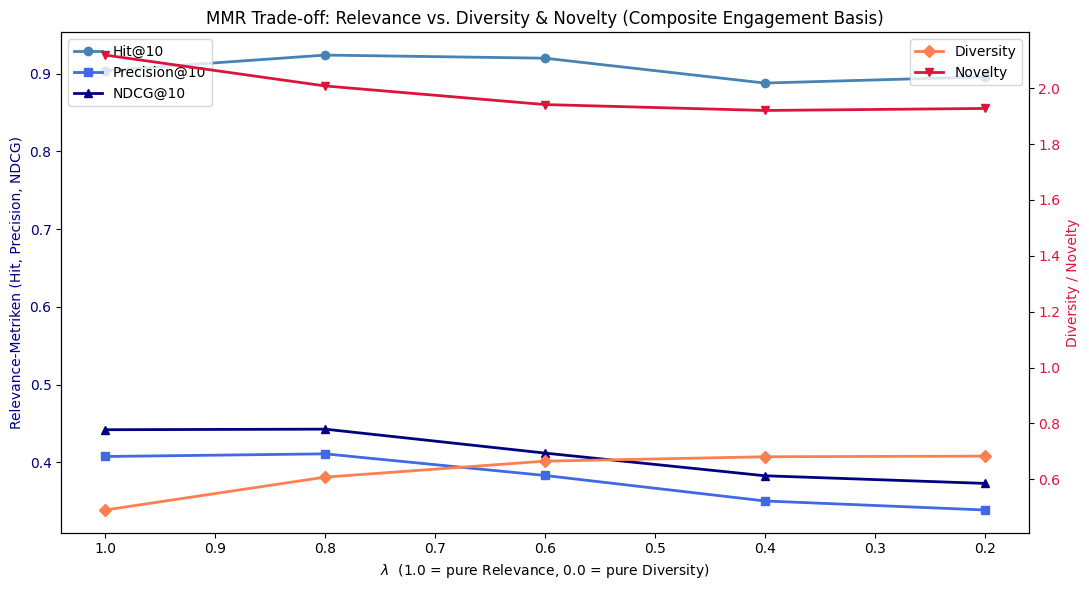

In [22]:
lambda_values = [1.0, 0.8, 0.6, 0.4, 0.2]
mmr_results = []
for lam in lambda_values:
    res = mmr_evaluate(cf_engagement, X_engagement, aid_to_idx_e, anime_ids_e,
                        content_norm, aid_e_to_idx, popularity_e, TOTAL_USERS_E,
                        eval_set, lambda_=lam)
    mmr_results.append({'lambda': lam, **res})
    print(f"lambda={lam:.1f}: Hit@10={res['Hit@10']*100:5.1f}%  Prec@10={res['Precision@10']:.3f}  "
          f"NDCG@10={res['NDCG@10']:.3f}  Diversity={res['Diversity']:.3f}  Novelty={res['Novelty']:.3f}")

df_sweep = pd.DataFrame(mmr_results)

# Trade-off Plot: zwei y-Achsen
fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

# Relevance-Metriken auf linker Achse
ax1.plot(df_sweep['lambda'], df_sweep['Hit@10'], 'o-', color='steelblue', label='Hit@10', linewidth=2)
ax1.plot(df_sweep['lambda'], df_sweep['Precision@10'], 's-', color='royalblue', label='Precision@10', linewidth=2)
ax1.plot(df_sweep['lambda'], df_sweep['NDCG@10'], '^-', color='navy', label='NDCG@10', linewidth=2)
ax1.set_xlabel(r'$\lambda$  (1.0 = pure Relevance, 0.0 = pure Diversity)')
ax1.set_ylabel('Relevance-Metriken (Hit, Precision, NDCG)', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.invert_xaxis()  # 1.0 links, 0.2 rechts -- "weniger Relevance" nach rechts

# Diversity/Novelty auf rechter Achse
ax2.plot(df_sweep['lambda'], df_sweep['Diversity'], 'D-', color='coral', label='Diversity', linewidth=2)
ax2.plot(df_sweep['lambda'], df_sweep['Novelty'], 'v-', color='crimson', label='Novelty', linewidth=2)
ax2.set_ylabel('Diversity / Novelty', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title(f'MMR Trade-off: Relevance vs. Diversity & Novelty (Composite Engagement Basis)')
plt.tight_layout()
plt.show()

### 4.12 Vollvergleich — 5 Varianten x 5 Metriken

Vergleich aller bisherigen Varianten plus zwei MMR-Auspraegungen (lambda=0.6 als "balanced", lambda=0.3 als "diverse"). Tabelle + Bar-Plot.

            Variante  n_eval  Hit@10  Precision@10  NDCG@10  Diversity  Novelty
      Rating-basiert     500   0.898        0.4124   0.4455     0.4824   2.2026
Composite Engagement     500   0.904        0.4076   0.4420     0.4902   2.1185
  Hybrid (alpha=0.7)     500   0.898        0.3510   0.3822     0.3447   2.3753
    MMR (lambda=0.6)     500   0.920        0.3832   0.4120     0.6649   1.9414
    MMR (lambda=0.4)     500   0.888        0.3504   0.3828     0.6807   1.9202


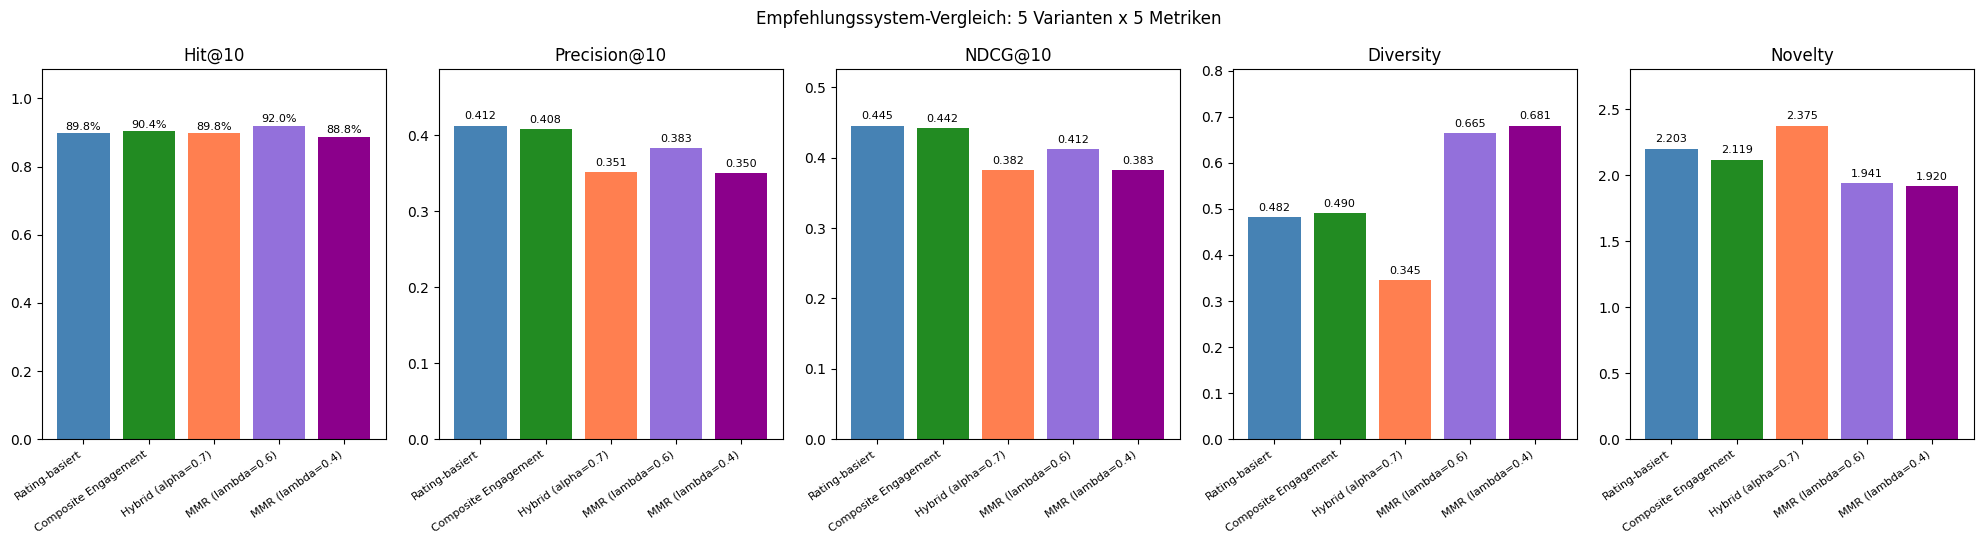

In [23]:
# MMR bei zwei ausgewaehlten lambda
res_mmr_06 = next(r for r in mmr_results if r['lambda'] == 0.6)
res_mmr_03 = next((r for r in mmr_results if r['lambda'] == 0.4), mmr_results[-1])

# Vollvergleich
final_data = [
    {'Variante': 'Rating-basiert', **res_rating_full},
    {'Variante': 'Composite Engagement', **res_engagement_full},
    {'Variante': f'Hybrid (alpha={ALPHA})', **res_hybrid_full},
    {'Variante': 'MMR (lambda=0.6)', **{k: v for k, v in res_mmr_06.items() if k != 'lambda'}},
    {'Variante': 'MMR (lambda=0.4)', **{k: v for k, v in res_mmr_03.items() if k != 'lambda'}},
]
df_final = pd.DataFrame(final_data).round(4)
print(df_final.to_string(index=False))

# Bar-Plot fuer alle 5 Metriken
fig, axes = plt.subplots(1, 5, figsize=(20, 5.5))
metrics_to_plot = ['Hit@10', 'Precision@10', 'NDCG@10', 'Diversity', 'Novelty']
variants = [r['Variante'] for r in final_data]
colors = ['steelblue', 'forestgreen', 'coral', 'mediumpurple', 'darkmagenta']

for ax, metric in zip(axes, metrics_to_plot):
    vals = [r[metric] for r in final_data]
    bars = ax.bar(range(len(variants)), vals, color=colors)
    ax.set_title(metric)
    ax.set_xticks(range(len(variants)))
    ax.set_xticklabels(variants, rotation=35, ha='right', fontsize=8)
    if metric == 'Hit@10':
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=8)
    else:
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + max(vals)*0.02, f'{v:.3f}', ha='center', fontsize=8)
    ax.set_ylim(0, max(vals) * 1.18)

plt.suptitle('Empfehlungssystem-Vergleich: 5 Varianten x 5 Metriken')
plt.tight_layout()
plt.show()

### 4.13 Multi-Seed Empfehlung

Bisher gibt man **einen** Anime an. Mit dem fertigen Modell (NearestNeighbors-Index ueber der Sparse-Matrix) koennen wir genauso gut **mehrere Seeds** akzeptieren -- ohne irgendetwas neu zu trainieren.

**Prinzip:**
1. Hol die Vektoren aller Seed-Animes
2. **Summiere/mittele** sie zu einem Centroid -- das ist die "gemeinsame Geschmacks-Signatur"
3. Suche die Nachbarn dieses Centroids

Cosine-Similarity ist skalen-invariant -> Summe und Mittelwert geben dieselbe Reihenfolge. Eine einzige `kneighbors`-Anfrage, billig.

**Plus MMR-Variante mit "Expand-Horizon":** die Diversity-Strafe schliesst nicht nur bereits gewaehlte Empfehlungen ein, sondern auch die Seed-Animes selbst. Dadurch werden Empfehlungen vermieden, die zu nah an dem liegen, was du eh schon kennst -- maximale Ueberraschung.

Drei Beispiel-Queries:
1. **Watanabe-Vibes** (kohaerent): *Cowboy Bebop + Samurai Champloo + Trigun*
2. **Psychologische Thriller** (kohaerent, anderes Genre): *Death Note + Code Geass + Monster*
3. **Stil-Mix** (kontrastiv): *Vinland Saga + K-On! + Cowboy Bebop* -- was bridged das?

In [24]:
def resolve_seeds(seed_names):
    """Names -> (mal_id, display_name) Liste, ueberspringt nicht gefundene."""
    resolved = []
    for name in seed_names:
        mal_id, display, _ = resolve_query(name)
        if mal_id is None:
            print(f"  ! '{name}' nicht gefunden -- uebersprungen")
            continue
        resolved.append((mal_id, display))
    return resolved


def recommend_multi(pipe, X, aid_to_idx, anime_ids, seed_aids, top_k=10):
    """Centroid-basierte Multi-Seed-Empfehlung."""
    seed_indices = [aid_to_idx[aid] for aid in seed_aids if aid in aid_to_idx]
    if not seed_indices:
        return None
    query = csr_matrix(np.asarray(X[seed_indices].sum(axis=0)))
    for _, step in pipe.steps[:-1]:
        query = step.transform(query)
    distances, indices = pipe.steps[-1][1].kneighbors(query, n_neighbors=top_k + len(seed_indices))

    seed_idx_set = set(seed_indices)
    out = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx in seed_idx_set:
            continue
        info = anime_info.loc[int(anime_ids[idx])]
        out.append({
            'Name': display_name(info), 'Type': info['Type'], 'Score': info['Score'],
            'Similarity': 1 - dist ** 2 / 2,
        })
        if len(out) >= top_k:
            break
    return pd.DataFrame(out).round(3)


def mmr_recommend_multi(pipe, X, aid_to_idx, anime_ids, content_norm_e, aid_e_to_idx,
                          seed_aids, lambda_=0.5, k=10, pool=50, expand_horizon=True):
    """Multi-Seed MMR. expand_horizon=True schliesst Seeds in Diversity-Strafe ein."""
    seed_indices = [aid_to_idx[aid] for aid in seed_aids if aid in aid_to_idx]
    if not seed_indices:
        return None
    seed_e_indices = [aid_e_to_idx[aid] for aid in seed_aids if aid in aid_e_to_idx]

    query = csr_matrix(np.asarray(X[seed_indices].sum(axis=0)))
    for _, step in pipe.steps[:-1]:
        query = step.transform(query)
    distances, indices = pipe.steps[-1][1].kneighbors(query, n_neighbors=pool + len(seed_indices))

    seed_idx_set = set(seed_indices)
    cand = []
    for dist, ri in zip(distances[0], indices[0]):
        if ri in seed_idx_set:
            continue
        aid = int(anime_ids[ri])
        if aid not in aid_e_to_idx:
            continue
        cand.append({'aid': aid, 'rel': 1 - dist ** 2 / 2, 'e_idx': aid_e_to_idx[aid]})

    selected = []
    sel_e_idx = list(seed_e_indices) if expand_horizon else []
    while len(selected) < k and cand:
        best, best_score = None, -np.inf
        for c in cand:
            if not sel_e_idx:
                div_pen = 0.0
            else:
                sims = (content_norm_e[c['e_idx']] @ content_norm_e[sel_e_idx].T)
                if hasattr(sims, 'toarray'):
                    sims = sims.toarray().flatten()
                else:
                    sims = sims.flatten()
                div_pen = float(sims.max())
            score = lambda_ * c['rel'] - (1 - lambda_) * div_pen
            if score > best_score:
                best_score, best = score, c
        selected.append(best)
        sel_e_idx.append(best['e_idx'])
        cand = [c for c in cand if c['aid'] != best['aid']]

    rows = []
    for c in selected:
        info = anime_info.loc[c['aid']]
        rows.append({
            'Name': display_name(info), 'Type': info['Type'], 'Score': info['Score'],
            'Relevance': round(c['rel'], 3),
        })
    return pd.DataFrame(rows)

#### Drei Beispiel-Queries (kohärent → kontrastiv)

In [25]:
queries = [
    ('Watanabe-Vibes (kohaerent)',
     ['Cowboy Bebop', 'Samurai Champloo', 'Trigun']),
    ('Psychologische Thriller (kohaerent)',
     ['Death Note', 'Code Geass', 'Monster']),
    ('Stil-Mix Hardcore-Test (kontrastiv)',
     ['Vinland Saga', 'K-On!', 'Cowboy Bebop']),
]

for label, seed_names in queries:
    print(f"\n{'='*100}")
    print(f"Query: {label}")
    print(f"Seeds: {seed_names}")
    print('='*100)

    resolved = resolve_seeds(seed_names)
    seed_aids = [aid for aid, _ in resolved]
    print(f"Aufgeloest: {', '.join(name for _, name in resolved)}\n")

    print("[ Centroid (pure CF) ]")
    df1 = recommend_multi(cf_engagement, X_engagement, aid_to_idx_e, anime_ids_e, seed_aids, top_k=10)
    if df1 is not None:
        print(df1.to_string(index=False))

    print(f"\n[ MMR (lambda=0.5) + Expand-Horizon ]")
    df2 = mmr_recommend_multi(cf_engagement, X_engagement, aid_to_idx_e, anime_ids_e,
                                content_norm, aid_e_to_idx, seed_aids,
                                lambda_=0.5, k=10, expand_horizon=True)
    if df2 is not None:
        print(df2.to_string(index=False))


Query: Watanabe-Vibes (kohaerent)
Seeds: ['Cowboy Bebop', 'Samurai Champloo', 'Trigun']
Aufgeloest: Cowboy Bebop, Samurai Champloo, Trigun

[ Centroid (pure CF) ]


                               Name Type  Score  Similarity
                      Gurren Lagann   TV   8.66       0.692
            Neon Genesis Evangelion   TV   8.32       0.677
                               FLCL  OVA   8.03       0.670
                       Black Lagoon   TV   8.05       0.670
                           Baccano!   TV   8.42       0.663
    Fullmetal Alchemist:Brotherhood   TV   9.19       0.656
                         Death Note   TV   8.63       0.650
Code Geass:Lelouch of the Rebellion   TV   8.72       0.647
                Fullmetal Alchemist   TV   8.17       0.633
                  Darker than Black   TV   8.12       0.627

[ MMR (lambda=0.5) + Expand-Horizon ]


                 Name  Type  Score  Relevance
    Hellsing Ultimate   OVA   8.40      0.590
 Howl's Moving Castle Movie   8.67      0.572
           Death Note    TV   8.63      0.650
                 FLCL   OVA   8.03      0.670
            Mushi-Shi    TV   8.69      0.621
            Toradora!    TV   8.24      0.571
    Princess Mononoke Movie   8.72      0.625
          Steins;Gate    TV   9.11      0.617
        Spirited Away Movie   8.83      0.624
Welcome to the N.H.K.    TV   8.33      0.610

Query: Psychologische Thriller (kohaerent)
Seeds: ['Death Note', 'Code Geass', 'Monster']
Aufgeloest: Death Note, Code Geass:Lelouch of the Rebellion, Monster

[ Centroid (pure CF) ]


                                  Name Type  Score  Similarity
Code Geass:Lelouch of the Rebellion R2   TV   8.91       0.848
       Fullmetal Alchemist:Brotherhood   TV   9.19       0.792
                       Attack on Titan   TV   8.48       0.781
                           Steins;Gate   TV   9.11       0.769
                          Angel Beats!   TV   8.15       0.721
                            Elfen Lied   TV   7.56       0.718
                                Naruto   TV   7.91       0.718
                      Sword Art Online   TV   7.25       0.715
                         One Punch Man   TV   8.57       0.711
                      The Future Diary   TV   7.54       0.710

[ MMR (lambda=0.5) + Expand-Horizon ]


                                    Name  Type  Score  Relevance
                        Sword Art Online    TV   7.25      0.715
                             Steins;Gate    TV   9.11      0.769
                           Spirited Away Movie   8.83      0.679
         Fullmetal Alchemist:Brotherhood    TV   9.19      0.792
                                 Clannad    TV   8.07      0.679
                 High School of the Dead    TV   7.15      0.659
                           One Punch Man    TV   8.57      0.711
                          Bakemonogatari    TV   8.36      0.686
                           Gurren Lagann    TV   8.66      0.709
Re:ZERO -Starting Life in Another World-    TV   8.29      0.639

Query: Stil-Mix Hardcore-Test (kontrastiv)
Seeds: ['Vinland Saga', 'K-On!', 'Cowboy Bebop']
Aufgeloest: Vinland Saga, K-ON!, Cowboy Bebop

[ Centroid (pure CF) ]


                               Name Type  Score  Similarity
                        Steins;Gate   TV   9.11       0.716
    Fullmetal Alchemist:Brotherhood   TV   9.19       0.710
                         Death Note   TV   8.63       0.706
                      Gurren Lagann   TV   8.66       0.703
                     Bakemonogatari   TV   8.36       0.695
            Neon Genesis Evangelion   TV   8.32       0.695
                          Toradora!   TV   8.24       0.693
                    Attack on Titan   TV   8.48       0.693
Code Geass:Lelouch of the Rebellion   TV   8.72       0.692
                      One Punch Man   TV   8.57       0.680

[ MMR (lambda=0.5) + Expand-Horizon ]


                                    Name  Type  Score  Relevance
                          Bakemonogatari    TV   8.36      0.695
                             Steins;Gate    TV   9.11      0.716
                              Your Name. Movie   8.96      0.636
                        No Game, No Life    TV   8.20      0.638
                   Welcome to the N.H.K.    TV   8.33      0.616
                        The Future Diary    TV   7.54      0.617
Re:ZERO -Starting Life in Another World-    TV   8.29      0.629
                                    FLCL   OVA   8.03      0.624
                       Princess Mononoke Movie   8.72      0.612
                         Attack on Titan    TV   8.48      0.693


## 5. Ergebnisse & Fazit

### Empfehlungssystem — 5 Varianten × 5 Metriken

| Variante | Hit@10 | Precision@10 | NDCG@10 | Diversity | Novelty |
|---|---|---|---|---|---|
| Rating-basiert | 89.8 % | 0.412 | 0.446 | 0.482 | 2.20 |
| Composite Engagement | 90.4 % | 0.408 | 0.442 | 0.490 | 2.12 |
| Hybrid (α=0.7) | 89.8 % | 0.351 | 0.382 | 0.345 | **2.38** |
| **MMR (λ=0.8)** | **92.4 %** | **0.411** | 0.443 | **0.608** | 2.01 |
| MMR (λ=0.4) | 88.8 % | 0.350 | 0.383 | 0.681 | 1.92 |

### Kern-Erkenntnisse

- **CF (Rating vs. Engagement) quantitativ gleichauf**: beide solide Baselines mit Hit@10 ~90 %
- **Hybrid (CF + Content)**: erhöht **Novelty** (Long-Tail-Treffer wie Golden Kamuy für Vinland Saga), kostet aber Precision/NDCG. Gut für Cold-Start, schlecht für reine User-Geschmacks-Vorhersage
- **MMR bei λ=0.8 ist Pareto-Verbesserung**: Hit@10 steigt sogar (+2pp), Precision/NDCG bleiben gleich, Diversity +24 %. Bei λ=0.6 noch mehr Diversity bei minimalem NDCG-Verlust
- **Novelty steigt mit MMR NICHT** — die Diversity-Strafe sortiert nur innerhalb der Top-50-Mainstream-Kandidaten um. Für mehr Long-Tail bräuchte es zusätzliche Popularitäts-Strafe
- **Multi-Seed funktioniert ohne Neutraining**: Centroid-Query macht "Empfiehl mir Anime für mein Geschmacksprofil aus diesen 3"

### Praktische Empfehlung

- **Standard-Empfehlung:** MMR bei λ=0.6–0.8 auf Composite Engagement
- **Cold-Start oder neuer Anime:** Hybrid-Variante (Content-Features helfen, wo CF kein Signal hat)
- **"Überrasch mich"-Anfrage:** MMR bei λ=0.4 mit Expand-Horizon (Seeds in Diversity-Strafe)
- **Multi-Anime-Affinität:** Centroid + MMR Multi-Seed

### Pipeline & Struktur

- `sklearn.Pipeline(Normalizer → NearestNeighbors)` als Basis
- MMR sitzt **post-hoc** auf der CF-Pipeline (kein Re-Training)
- Content-Features (Genres, Studio, Type, Rating, Source, Duration) ergänzen den User-Engagement-Vektor

Top-Anime-Analyse: siehe `01_top_anime.ipynb`.